In [16]:
import pandas as pd
df =pd.read_csv('lightgbm.csv')

read the data

In [17]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

No missing values (NaN) in any column.

In [18]:
# Print unique values for all string/object columns
for col in df.select_dtypes(include=['object']).columns:
  print(f"=== {col} ===")
  print(df[col].unique())
  print()

=== job ===
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

=== marital ===
['married' 'single' 'divorced' 'unknown']

=== education ===
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

=== default ===
['no' 'unknown' 'yes']

=== housing ===
['no' 'yes' 'unknown']

=== loan ===
['no' 'yes' 'unknown']

=== contact ===
['telephone' 'cellular']

=== month ===
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

=== day_of_week ===
['mon' 'tue' 'wed' 'thu' 'fri']

=== poutcome ===
['nonexistent' 'failure' 'success']

=== y ===
['no' 'yes']



Categorical columns contain no missing values either, but several use `'unknown'` as a placeholder (e.g. job, education, default, housing, loan) instead of a true NaN. `pdays` and `poutcome` also use special values (`999`, `'nonexistent'`) to represent "not previously contacted."

In [19]:
# Look at the max, min, and median of numeric features
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Numeric ranges look reasonable overall, but a few stand out: `duration` has a wide range with likely outliers (some calls very long), and `campaign` has a high max compared to its median, suggesting a few clients were contacted many more times than typical. `pdays` is dominated by the placeholder value 999.

In [20]:
# Count how many times 'unknown' appears in each column
(df == 'unknown').sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

`'unknown'` appears mainly in `job`, `marital`, `education`, `default`, `housing`, and `loan` — with `default` having the highest count. These are not true missing values; they'll be kept as-is and treated as a valid category.

1. DATASET OVERVIEW & STRUCTURAL HEALTH CHECK

📊 Data Dimensions:
   - Number of Rows: 41,188
   - Number of Columns: 20

📋 Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

💾 Memory Usage:
   - Total Memory: 29.95 MB

   Per Column Memory Usage:
Index                 132
age                329504
job               2716564
marital           2629076
education         2871255
default           2473080
housing           2456618
loan              2441290
contact           2692264
month             2471

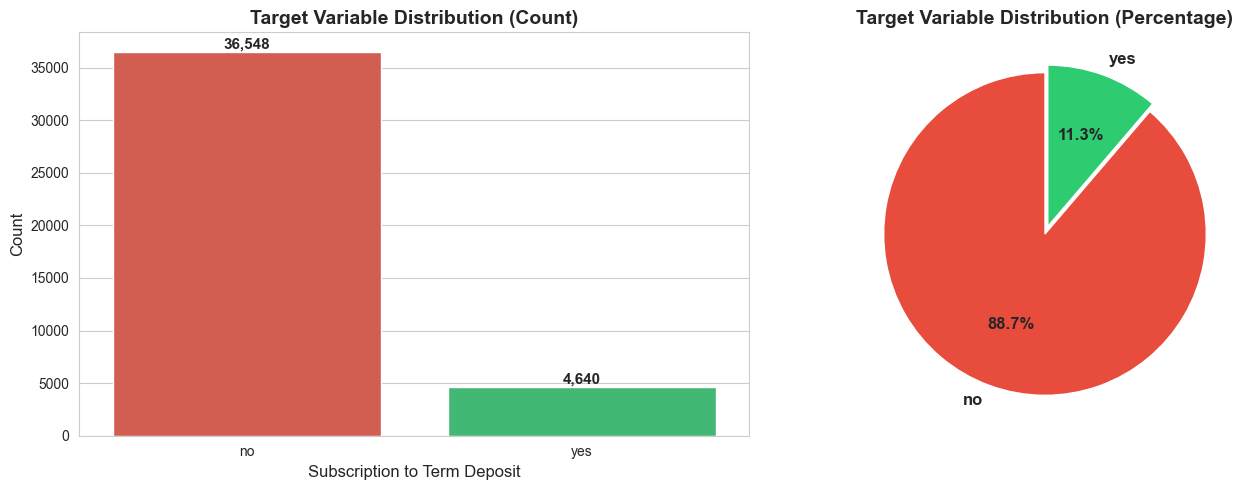


3. UNIVARIATE ANALYSIS — NUMERIC FEATURES

📊 Numeric Features Identified (9):
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

📈 Summary Statistics (describe()):
                    count      mean      std       min       25%       50%  \
age            41188.0000   40.0241  10.4212   17.0000   32.0000   38.0000   
campaign       41188.0000    2.5676   2.7700    1.0000    1.0000    2.0000   
pdays          41188.0000  962.4755 186.9109    0.0000  999.0000  999.0000   
previous       41188.0000    0.1730   0.4949    0.0000    0.0000    0.0000   
emp.var.rate   41188.0000    0.0819   1.5710   -3.4000   -1.8000    1.1000   
cons.price.idx 41188.0000   93.5757   0.5788   92.2010   93.0750   93.7490   
cons.conf.idx  41188.0000  -40.5026   4.6282  -50.8000  -42.7000  -41.8000   
euribor3m      41188.0000    3.6213   1.7344    0.6340    1.3440    4.8570   
nr.employed    41188.0000 5167.0359  72.2515 4963.6000 5099.100

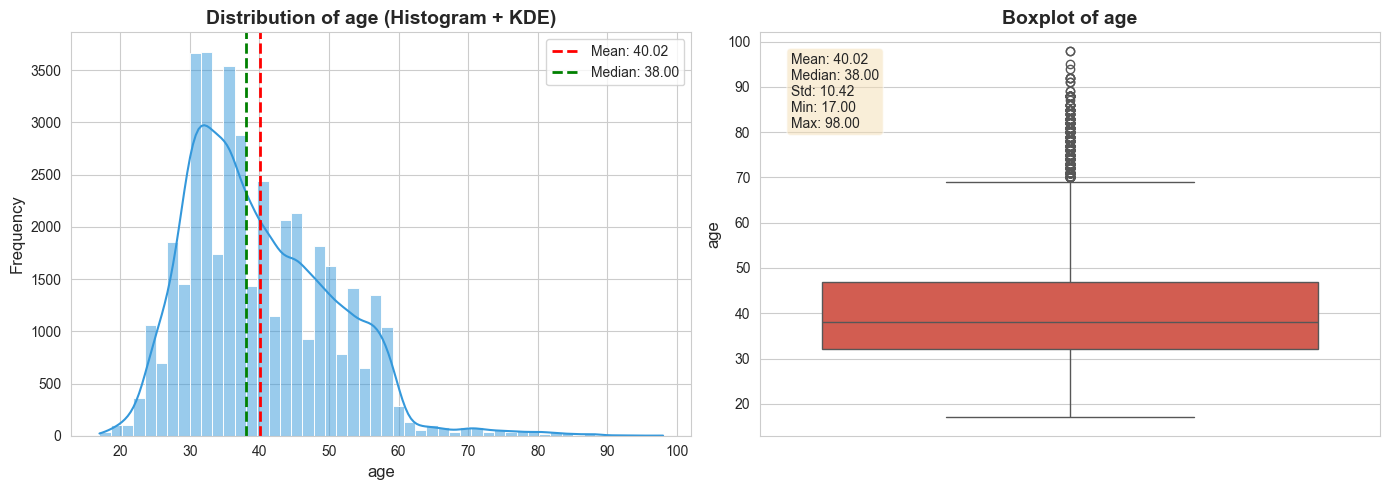

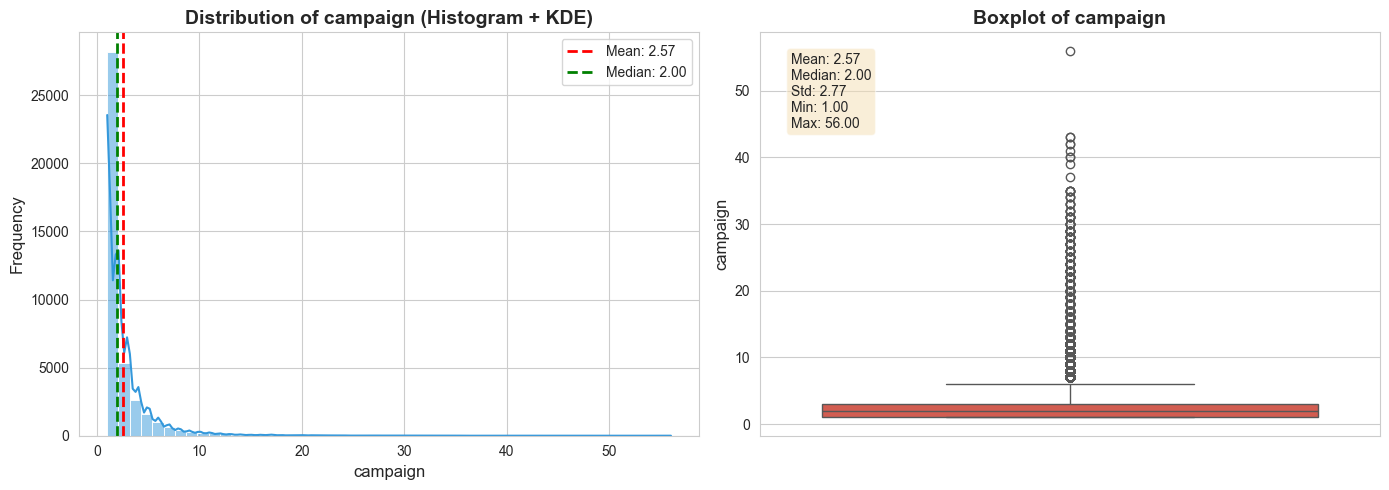

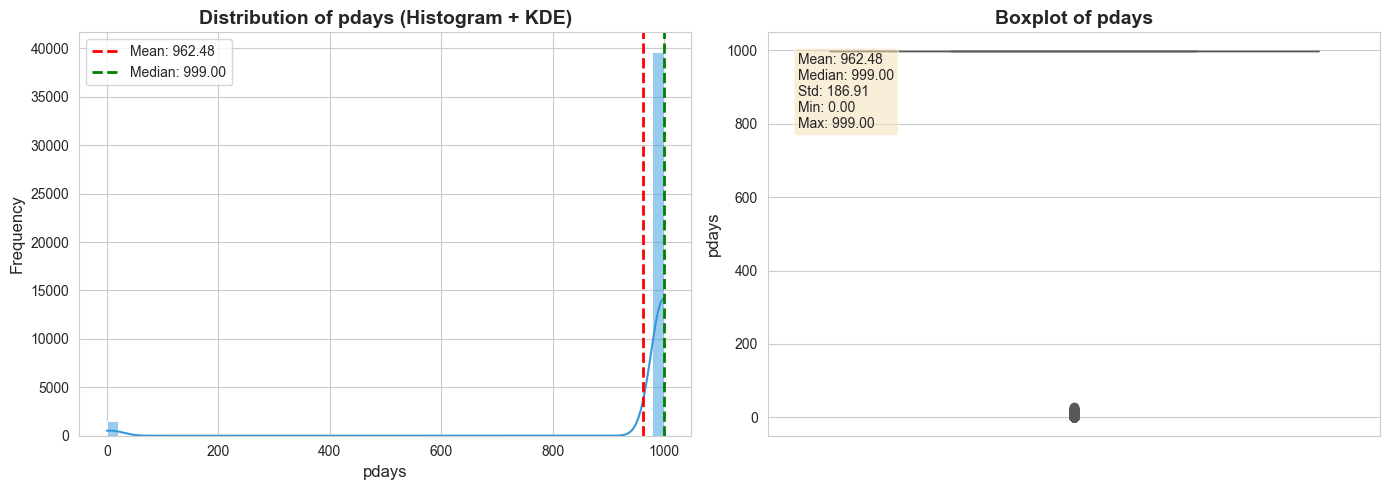

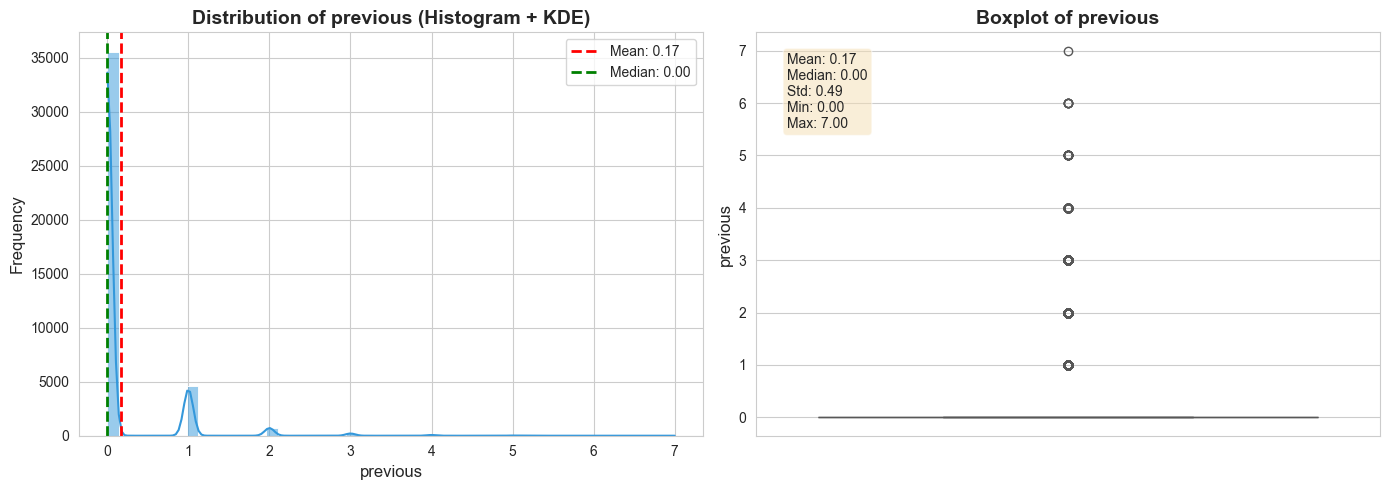

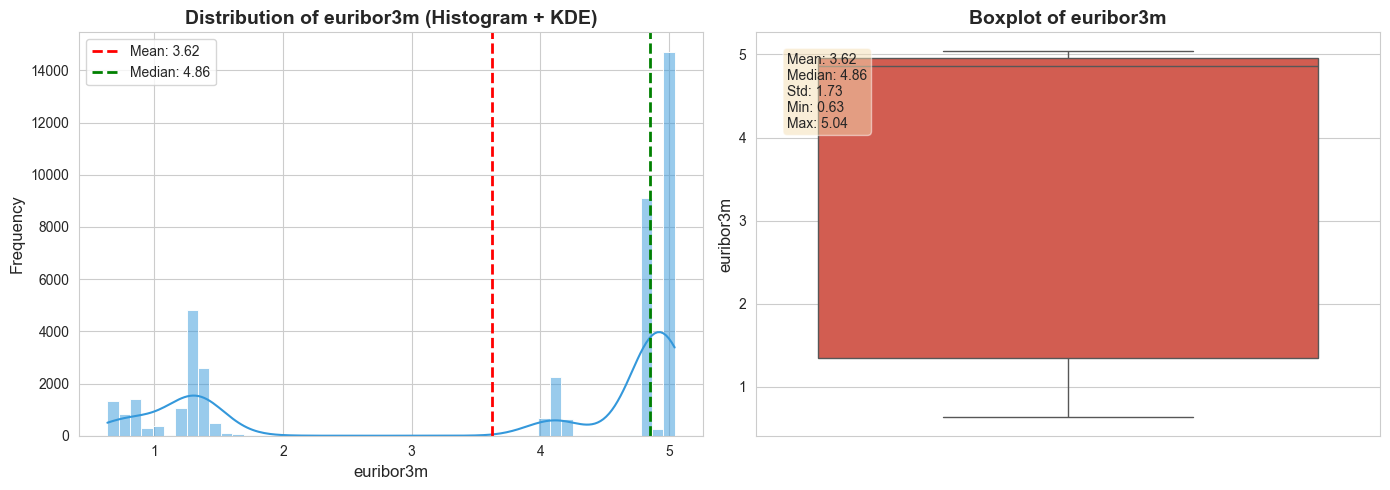

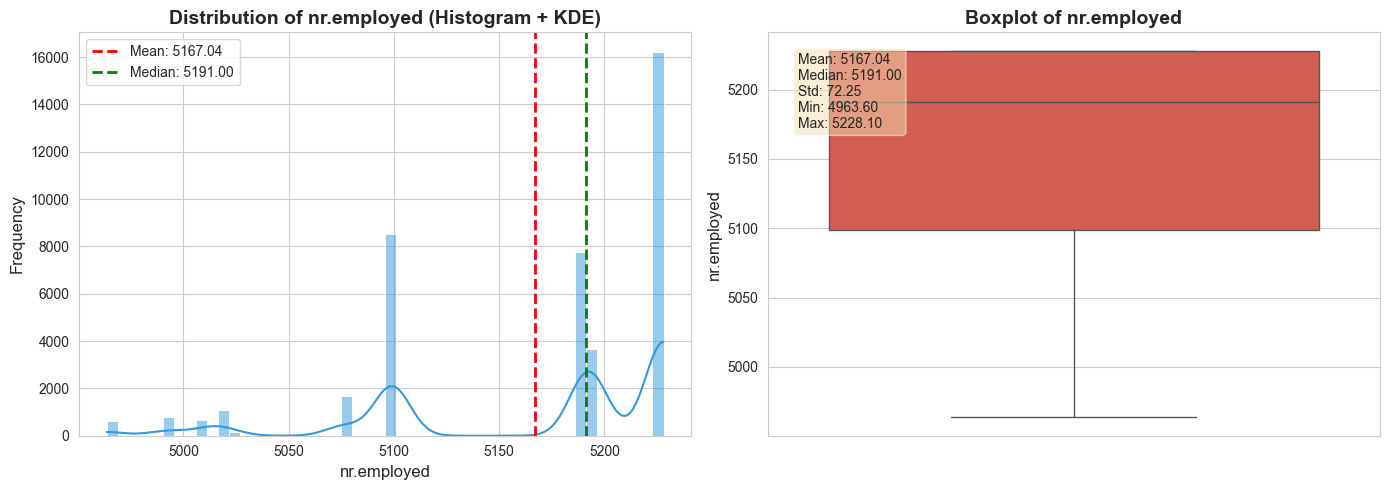

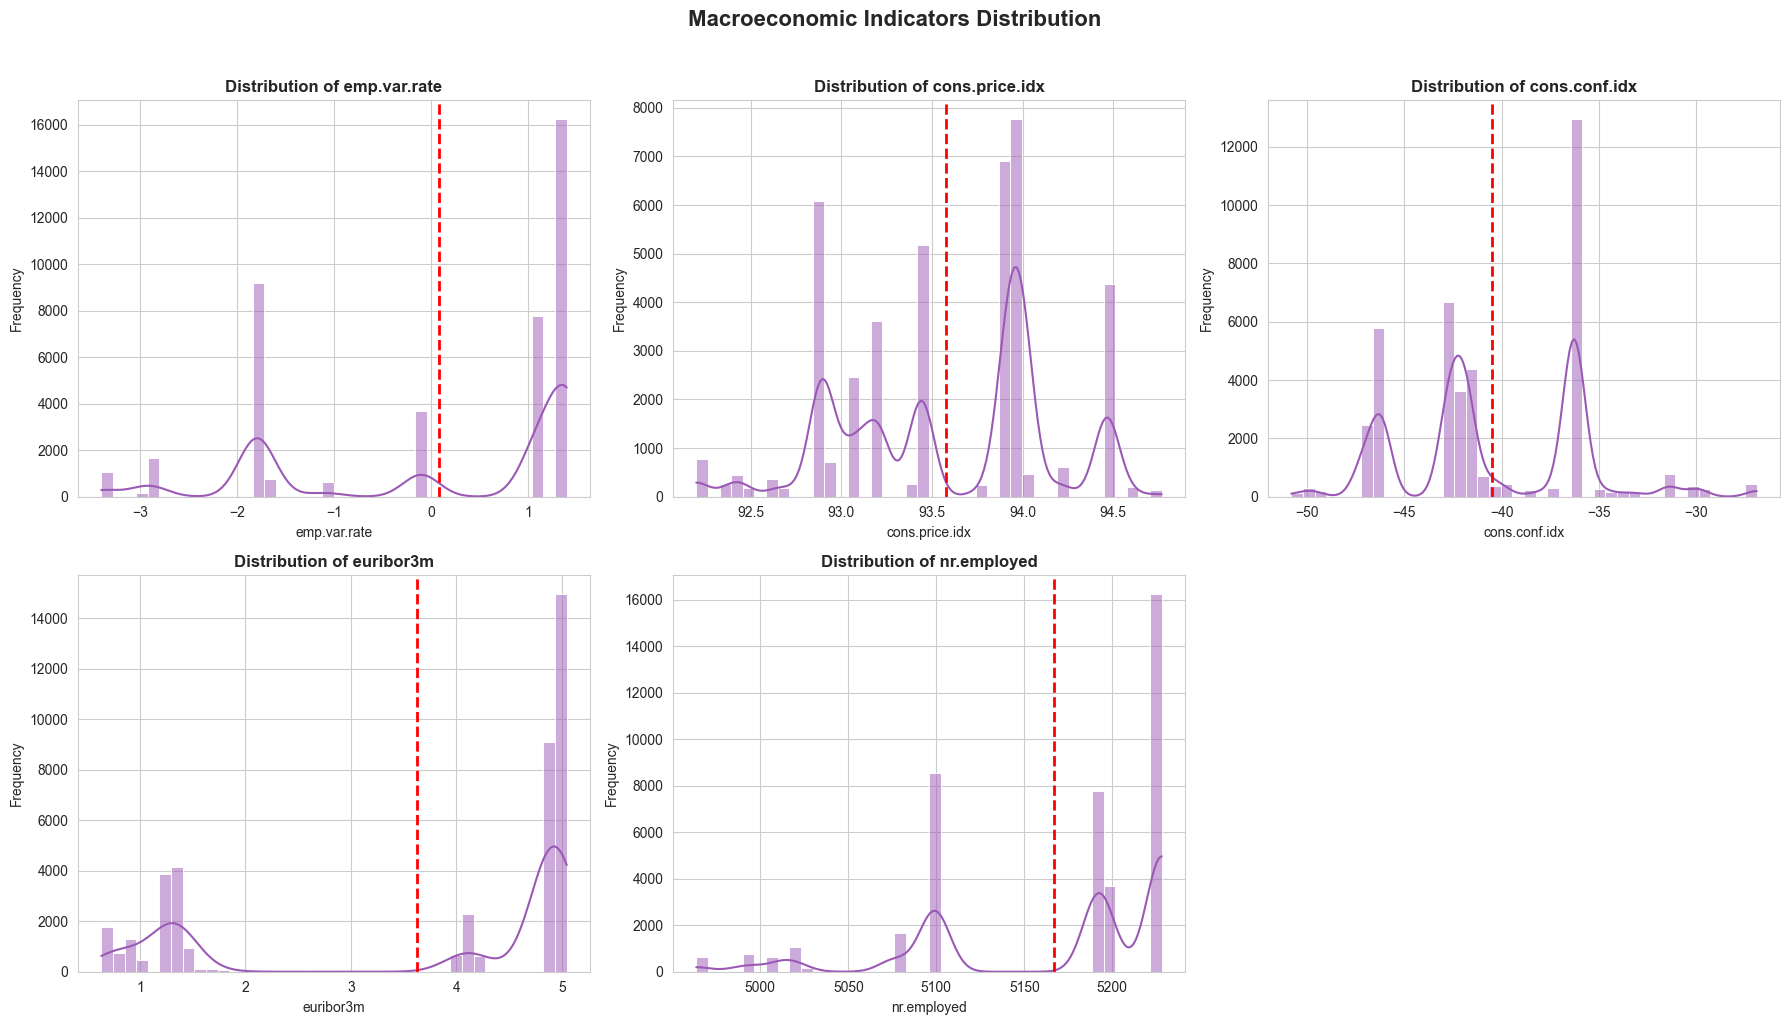


4. UNIVARIATE ANALYSIS — CATEGORICAL FEATURES

📊 Categorical Features Identified (10):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

📌 Feature: job

   Proportion Table:
               Count  Percentage
job                             
admin.         10422     25.3000
blue-collar     9254     22.4700
technician      6743     16.3700
services        3969      9.6400
management      2924      7.1000
retired         1720      4.1800
entrepreneur    1456      3.5400
self-employed   1421      3.4500
housemaid       1060      2.5700
unemployed      1014      2.4600
student          875      2.1200
unknown          330      0.8000


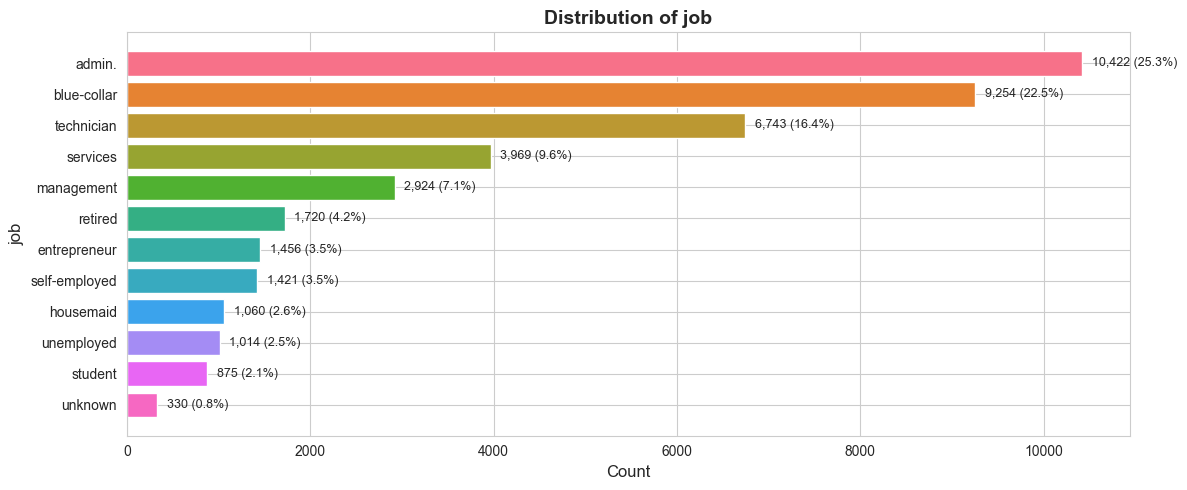


📌 Feature: marital

   Proportion Table:
          Count  Percentage
marital                    
married   24928     60.5200
single    11568     28.0900
divorced   4612     11.2000
unknown      80      0.1900


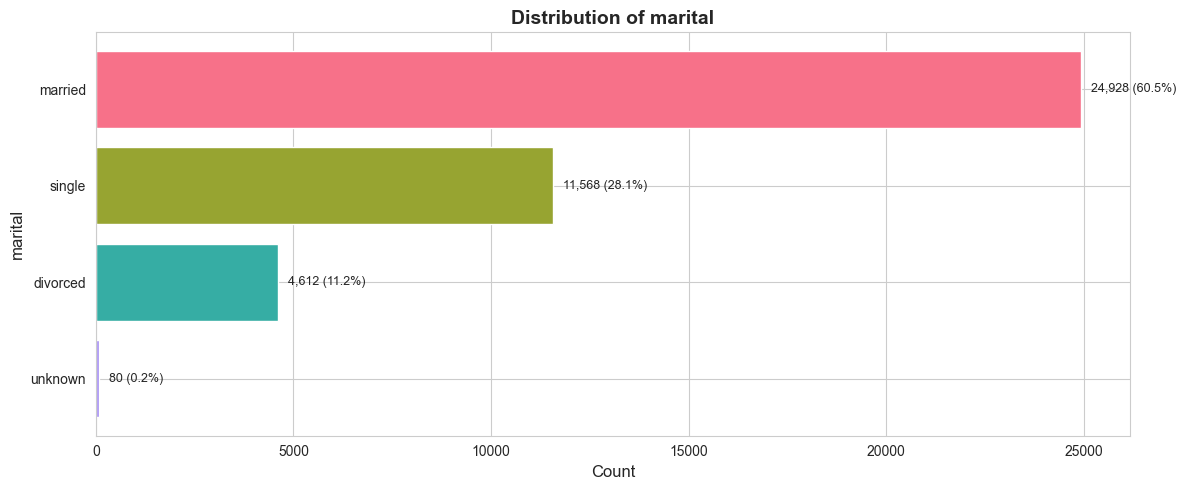


📌 Feature: education

   Proportion Table:
                     Count  Percentage
education                             
university.degree    12168     29.5400
high.school           9515     23.1000
basic.9y              6045     14.6800
professional.course   5243     12.7300
basic.4y              4176     10.1400
basic.6y              2292      5.5600
unknown               1731      4.2000
illiterate              18      0.0400


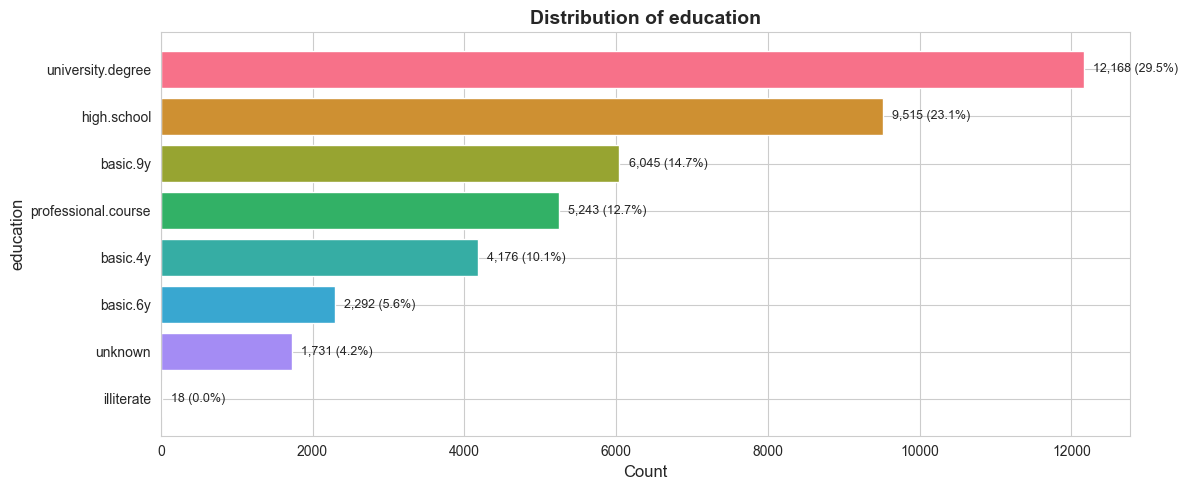


📌 Feature: default

   Proportion Table:
         Count  Percentage
default                   
no       32588     79.1200
unknown   8597     20.8700
yes          3      0.0100


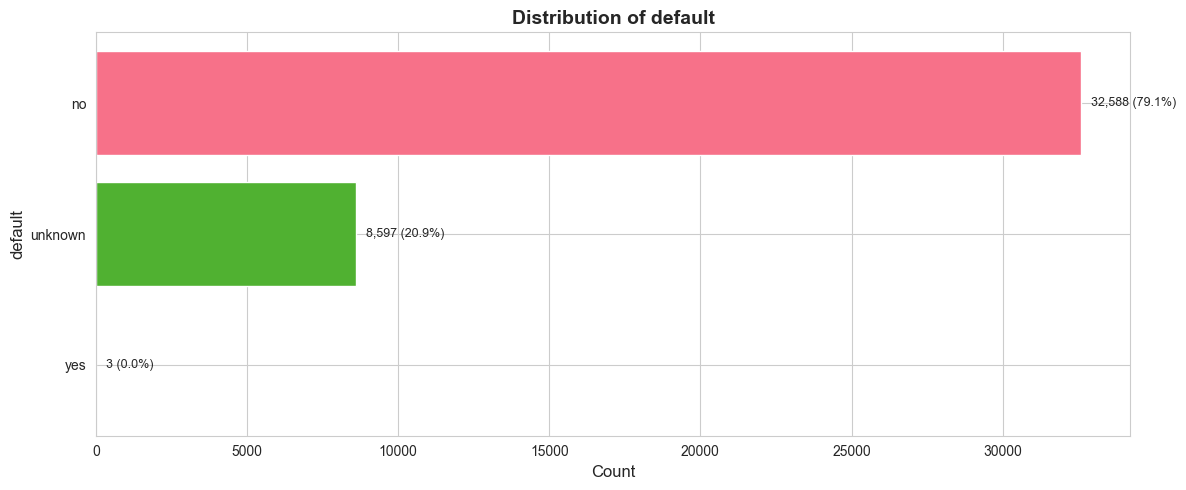


📌 Feature: housing

   Proportion Table:
         Count  Percentage
housing                   
yes      21576     52.3800
no       18622     45.2100
unknown    990      2.4000


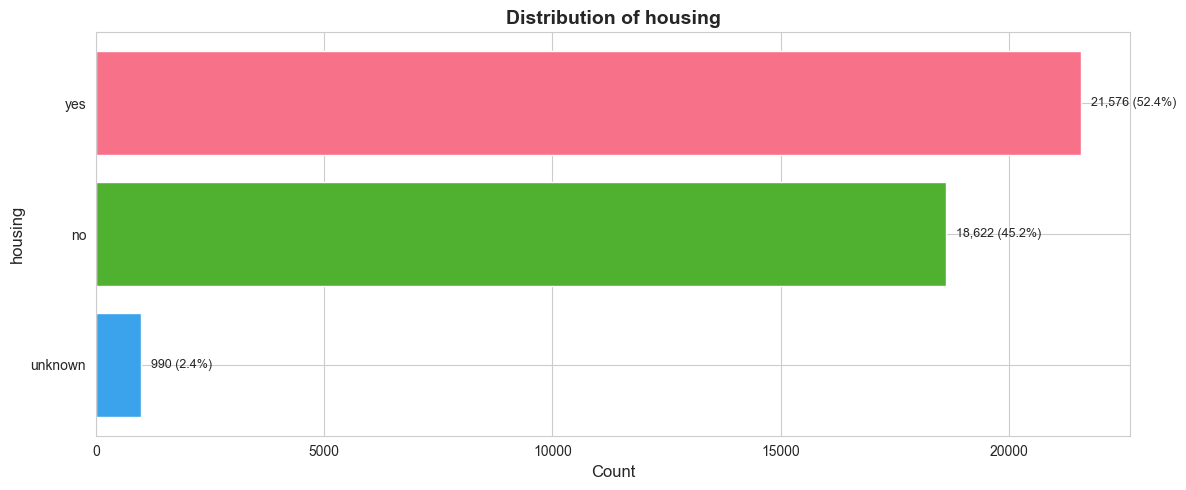


📌 Feature: loan

   Proportion Table:
         Count  Percentage
loan                      
no       33950     82.4300
yes       6248     15.1700
unknown    990      2.4000


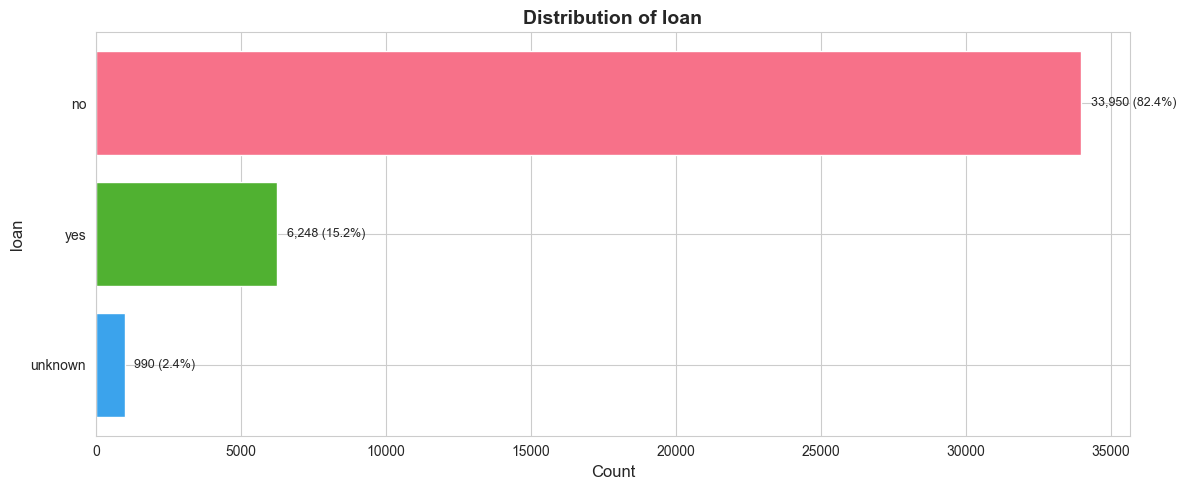


📌 Feature: contact

   Proportion Table:
           Count  Percentage
contact                     
cellular   26144     63.4700
telephone  15044     36.5300


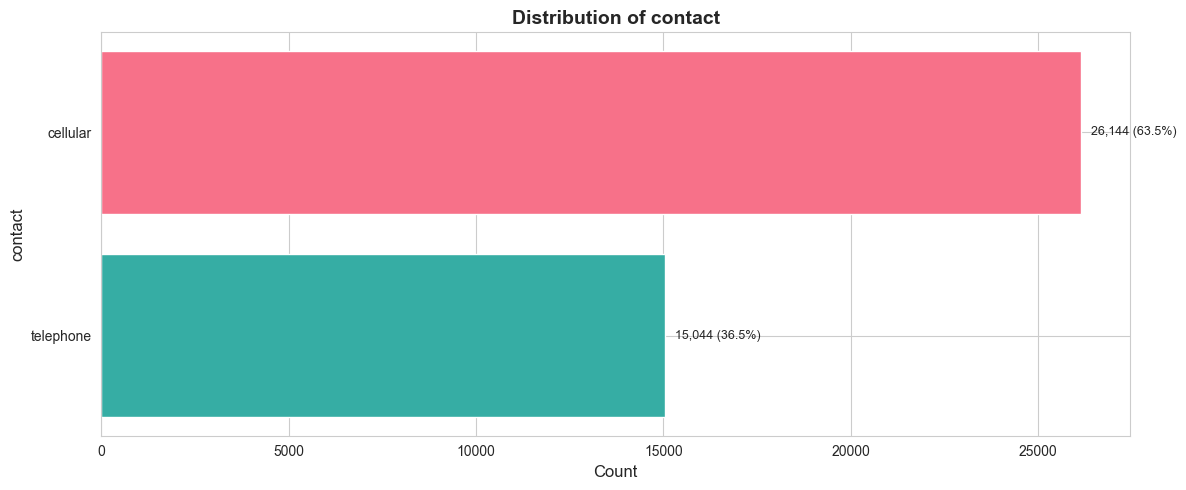


📌 Feature: month

   Proportion Table:
       Count  Percentage
month                   
may    13769     33.4300
jul     7174     17.4200
aug     6178     15.0000
jun     5318     12.9100
nov     4101      9.9600
apr     2632      6.3900
oct      718      1.7400
sep      570      1.3800
mar      546      1.3300
dec      182      0.4400


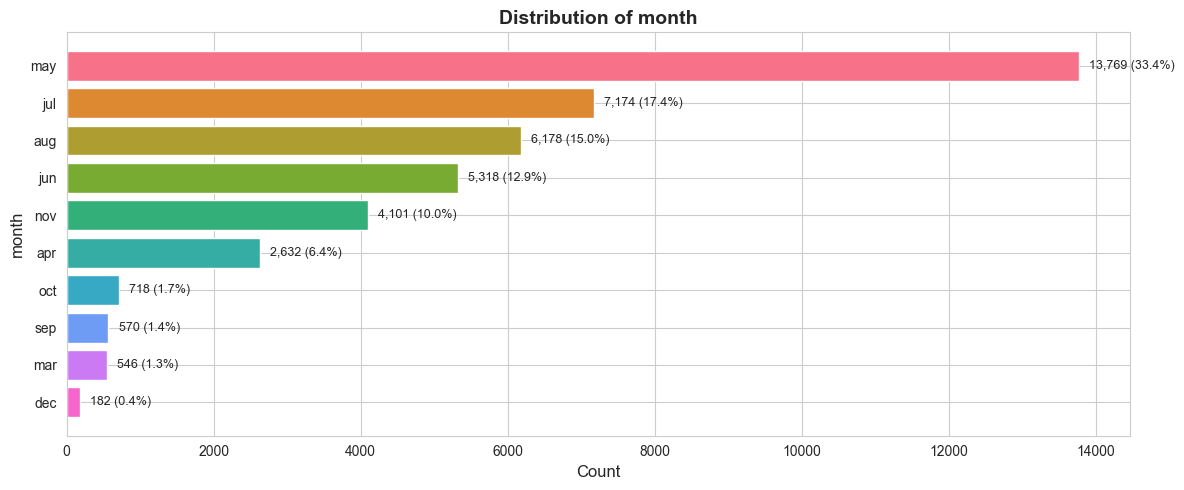


📌 Feature: day_of_week

   Proportion Table:
             Count  Percentage
day_of_week                   
thu           8623     20.9400
mon           8514     20.6700
wed           8134     19.7500
tue           8090     19.6400
fri           7827     19.0000


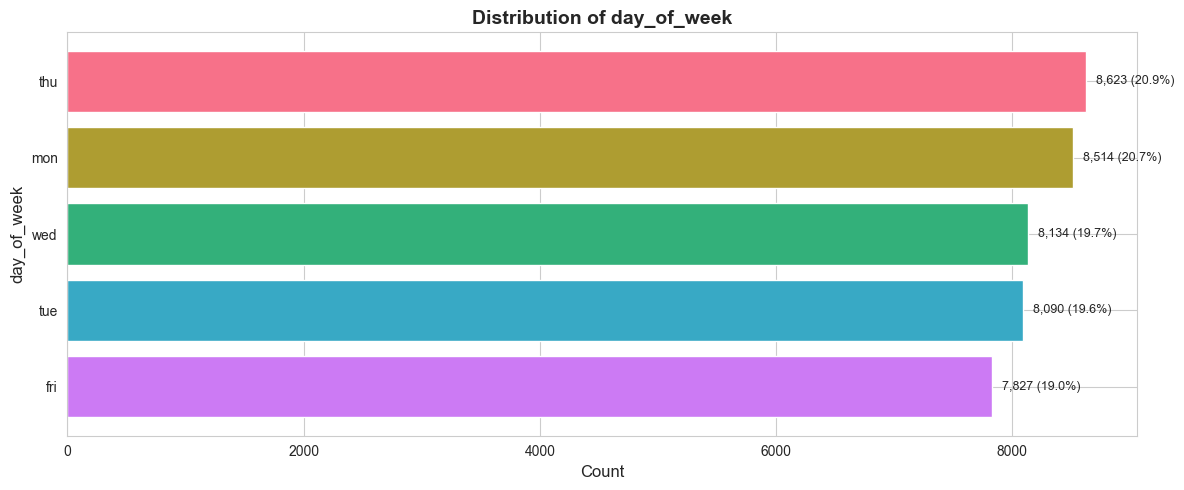


📌 Feature: poutcome

   Proportion Table:
             Count  Percentage
poutcome                      
nonexistent  35563     86.3400
failure       4252     10.3200
success       1373      3.3300


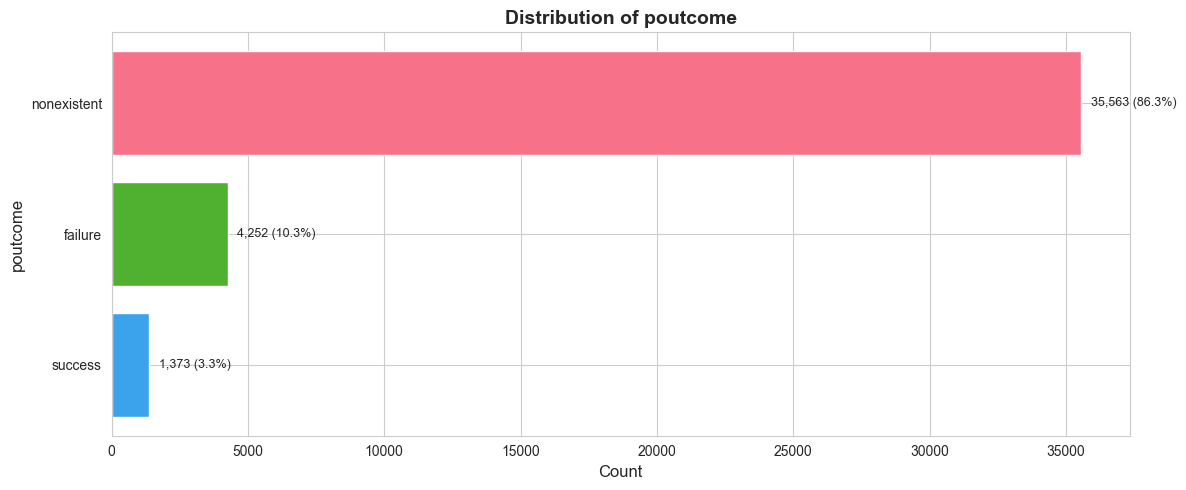


🔍 EXPLICIT AUDIT OF 'unknown' PLACEHOLDER FREQUENCIES

📊 Columns with 'unknown' values:
   Column  Unknown Count  Unknown Percentage  Total Categories
      job            330              0.8012                12
  marital             80              0.1942                 4
education           1731              4.2027                 8
  default           8597             20.8726                 3
  housing            990              2.4036                 3
     loan            990              2.4036                 3

   Total 'unknown' values across all columns: 12,718

🔍 EXPLICIT AUDIT OF 'nonexistent' PLACEHOLDER FREQUENCIES
  Column  Nonexistent Count  Nonexistent Percentage
poutcome              35563                 86.3431

🔍 EXPLICIT AUDIT OF NUMERIC PLACEHOLDER (999 in pdays)
   - pdays = 999 Count: 39,673
   - pdays = 999 Percentage: 96.32%
   - Interpretation: 999 is used as a placeholder for 'client was not previously contacted'

5. BIVARIATE ANALYSIS (FEATURES VS. T

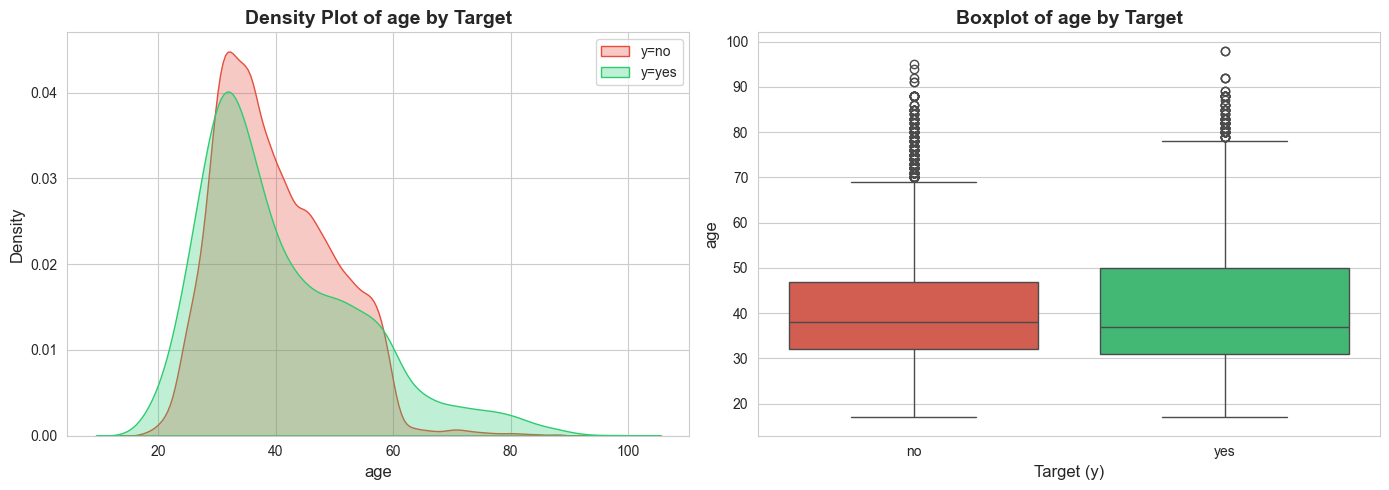

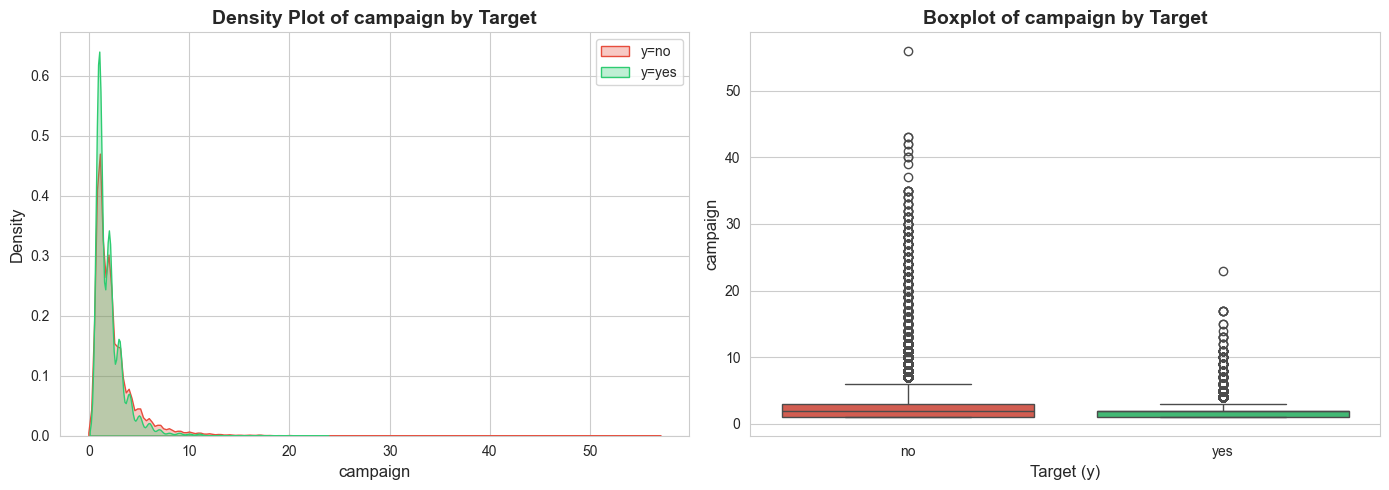

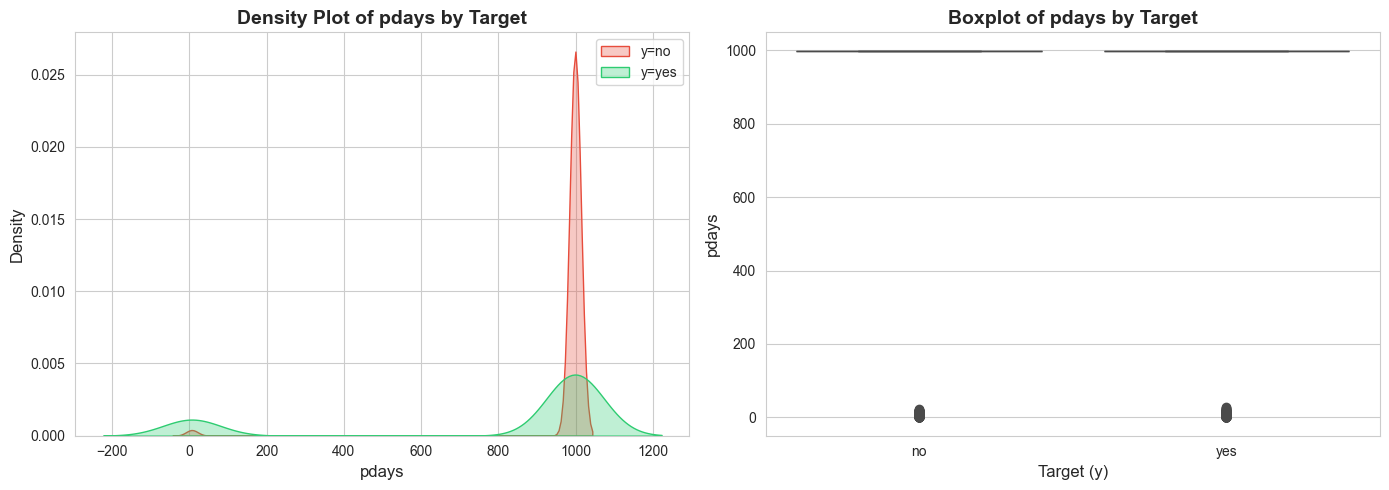

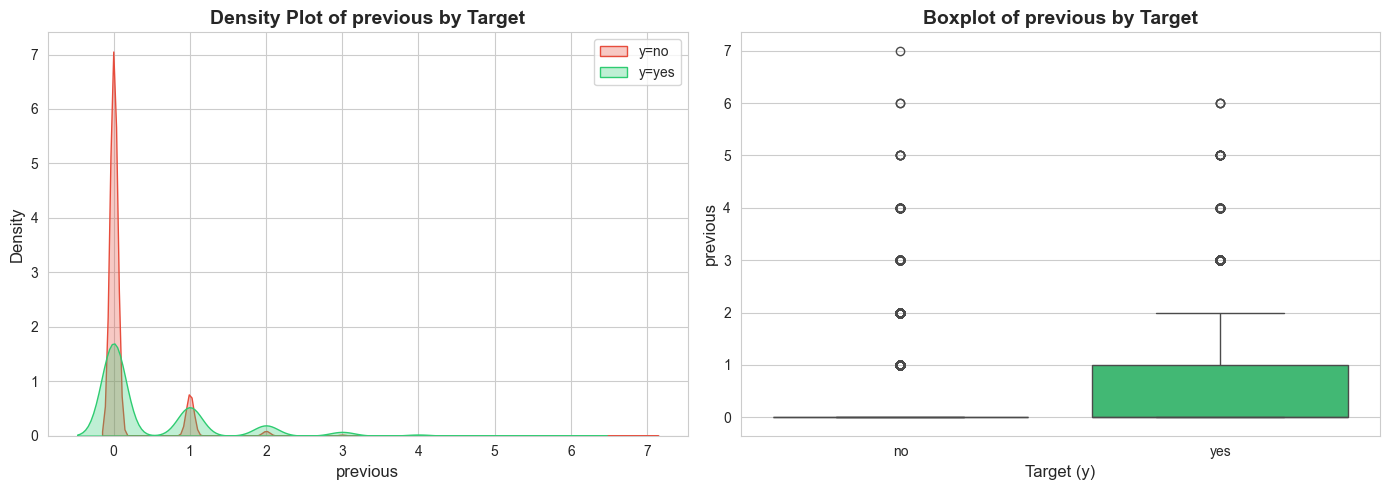

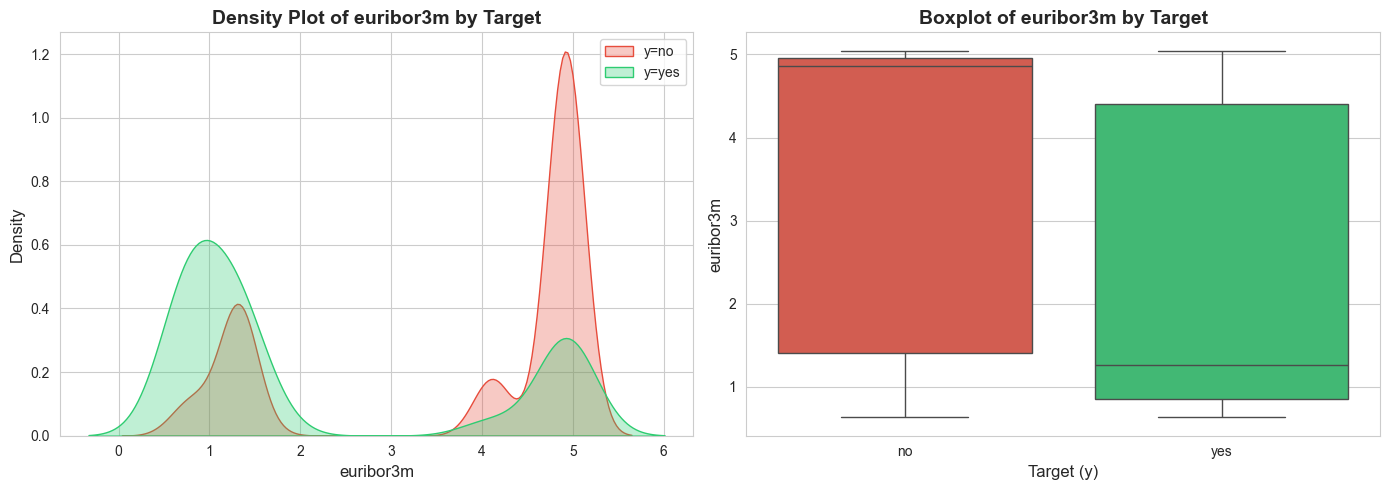

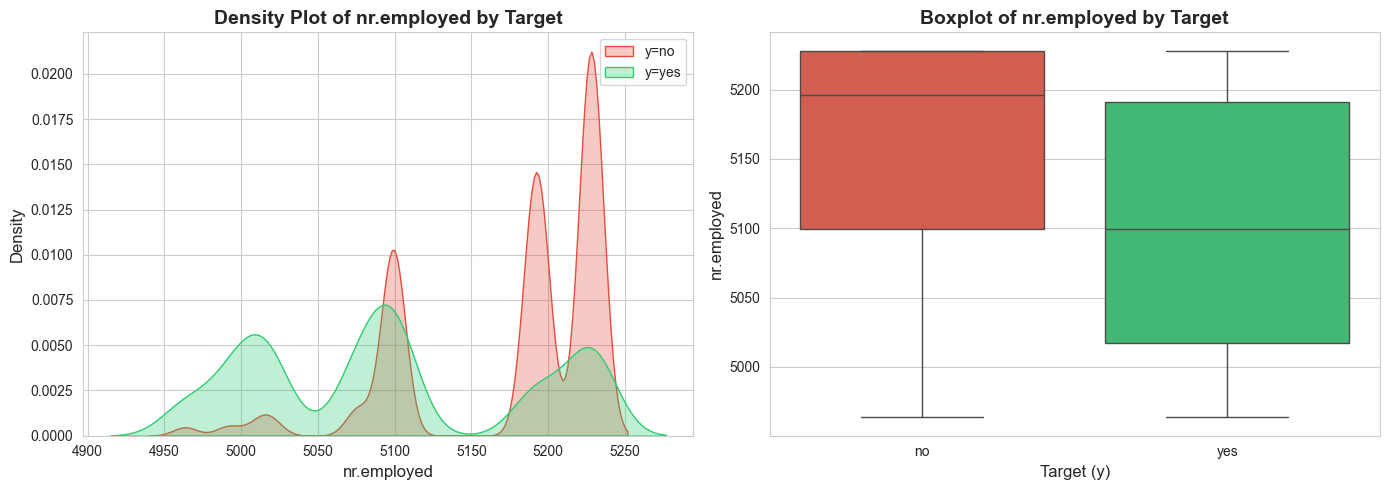


5b. CATEGORICAL FEATURES VS. TARGET

📌 Feature: job vs Target (y)

   Cross-Tabulation (Counts):
y                no   yes
job                      
admin.         9070  1352
blue-collar    8616   638
entrepreneur   1332   124
housemaid       954   106
management     2596   328
retired        1286   434
self-employed  1272   149
services       3646   323
student         600   275
technician     6013   730
unemployed      870   144
unknown         293    37

   Normalized Proportions (% by row):
y                  no     yes
job                          
admin.        87.0300 12.9700
blue-collar   93.1100  6.8900
entrepreneur  91.4800  8.5200
housemaid     90.0000 10.0000
management    88.7800 11.2200
retired       74.7700 25.2300
self-employed 89.5100 10.4900
services      91.8600  8.1400
student       68.5700 31.4300
technician    89.1700 10.8300
unemployed    85.8000 14.2000
unknown       88.7900 11.2100

   Chi-Square Test Results:
   - χ² Statistic: 961.2424
   - Degrees of Freedo

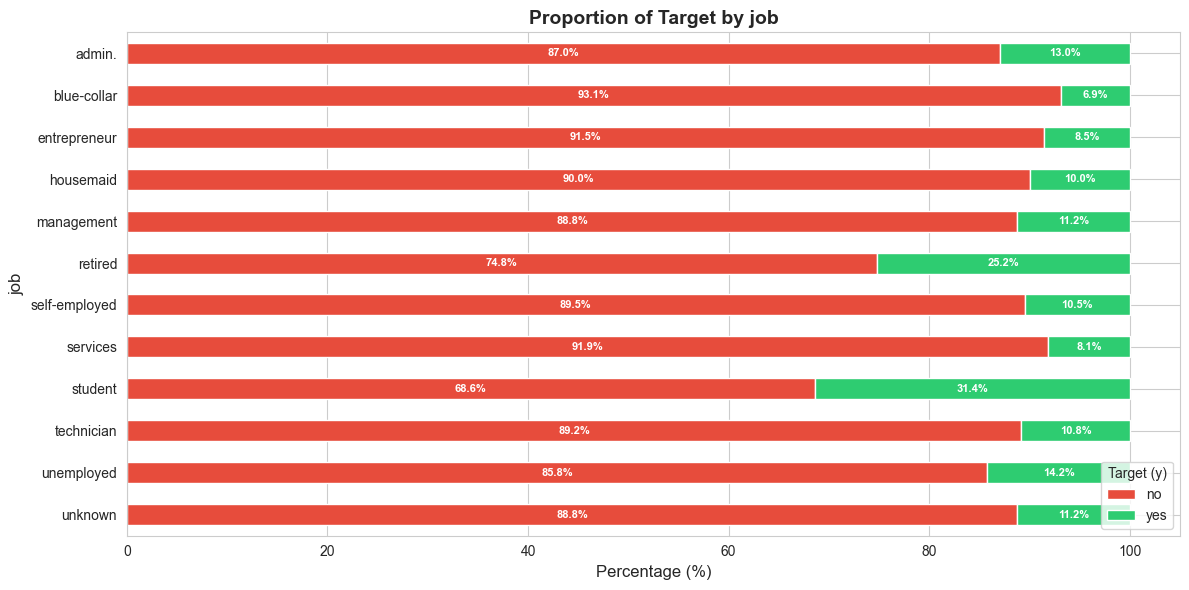


📌 Feature: marital vs Target (y)

   Cross-Tabulation (Counts):
y            no   yes
marital              
divorced   4136   476
married   22396  2532
single     9948  1620
unknown      68    12

   Normalized Proportions (% by row):
y             no     yes
marital                 
divorced 89.6800 10.3200
married  89.8400 10.1600
single   86.0000 14.0000
unknown  85.0000 15.0000

   Chi-Square Test Results:
   - χ² Statistic: 122.6552
   - Degrees of Freedom: 3
   - P-Value: 2.068015e-26
   - Cramér's V (Effect Size): 0.0546
   - Significance: *** (Highly Significant)


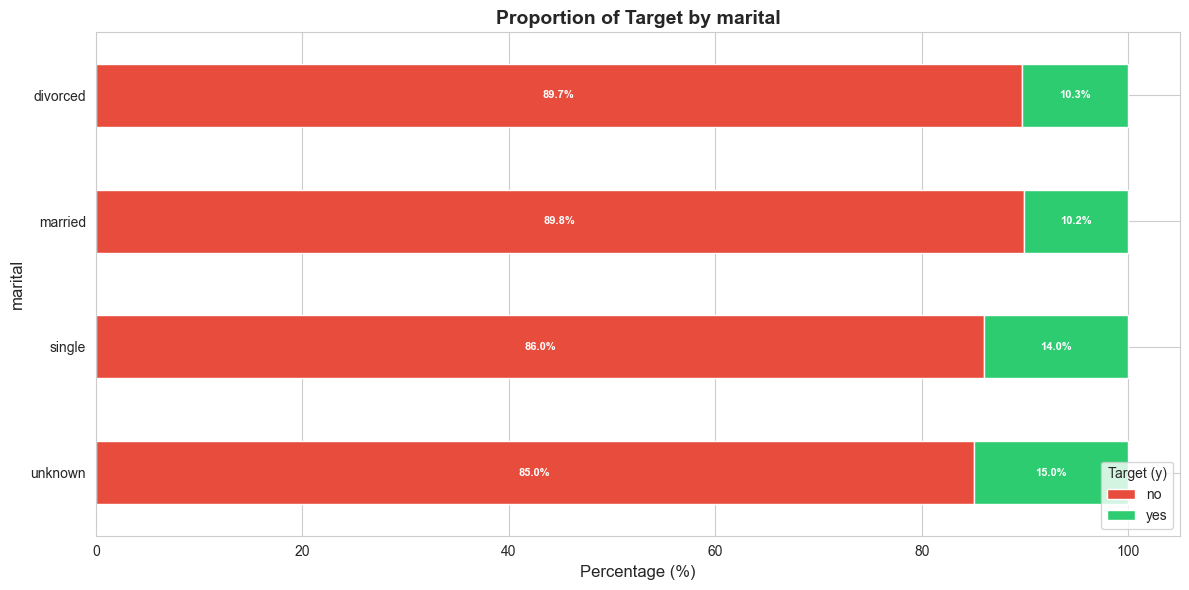


📌 Feature: education vs Target (y)

   Cross-Tabulation (Counts):
y                       no   yes
education                       
basic.4y              3748   428
basic.6y              2104   188
basic.9y              5572   473
high.school           8484  1031
illiterate              14     4
professional.course   4648   595
university.degree    10498  1670
unknown               1480   251

   Normalized Proportions (% by row):
y                        no     yes
education                          
basic.4y            89.7500 10.2500
basic.6y            91.8000  8.2000
basic.9y            92.1800  7.8200
high.school         89.1600 10.8400
illiterate          77.7800 22.2200
professional.course 88.6500 11.3500
university.degree   86.2800 13.7200
unknown             85.5000 14.5000

   Chi-Square Test Results:
   - χ² Statistic: 193.1059
   - Degrees of Freedom: 7
   - P-Value: 3.305189e-38
   - Cramér's V (Effect Size): 0.0685
   - Significance: *** (Highly Significant)


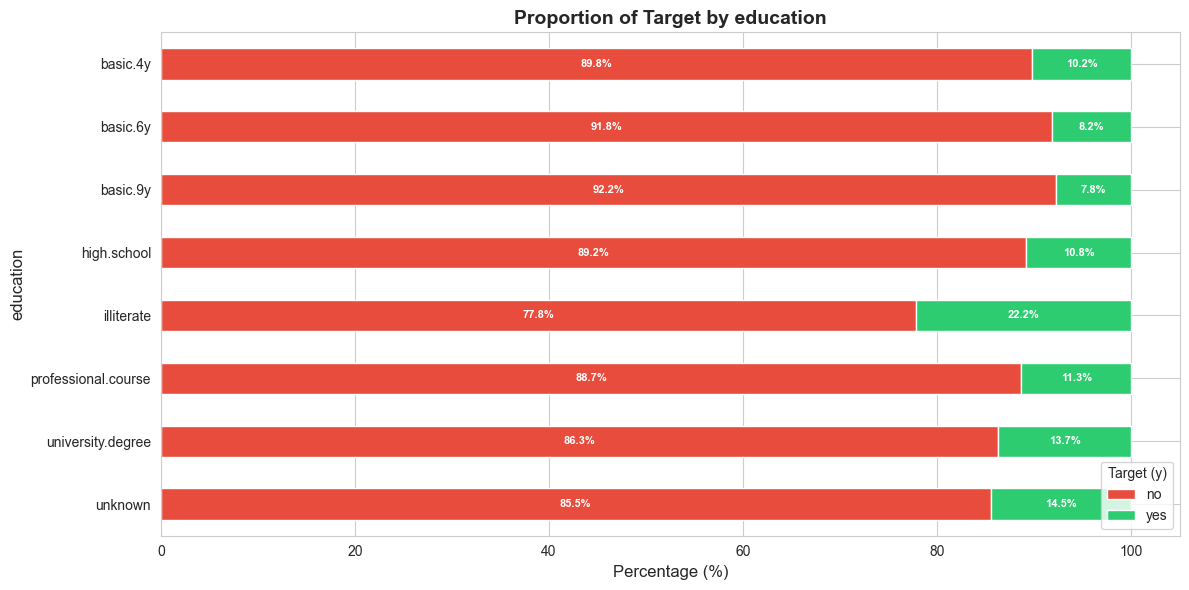


📌 Feature: default vs Target (y)

   Cross-Tabulation (Counts):
y           no   yes
default             
no       28391  4197
unknown   8154   443
yes          3     0

   Normalized Proportions (% by row):
y             no     yes
default                 
no       87.1200 12.8800
unknown  94.8500  5.1500
yes     100.0000  0.0000

   Chi-Square Test Results:
   - χ² Statistic: 406.5775
   - Degrees of Freedom: 2
   - P-Value: 5.161958e-89
   - Cramér's V (Effect Size): 0.0994
   - Significance: *** (Highly Significant)


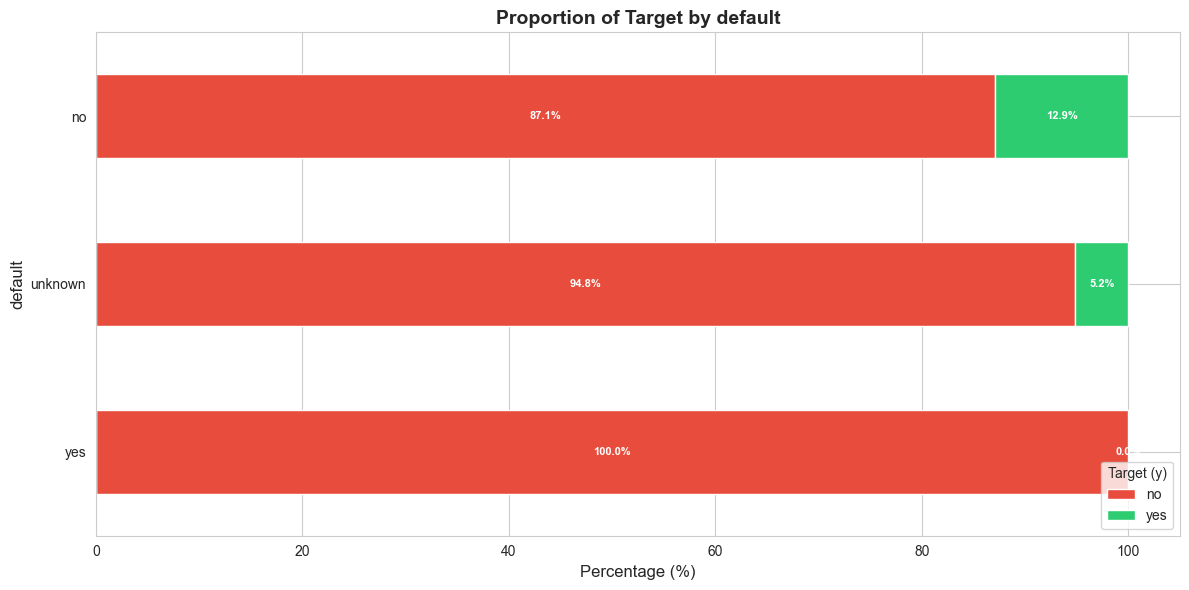


📌 Feature: housing vs Target (y)

   Cross-Tabulation (Counts):
y           no   yes
housing             
no       16596  2026
unknown    883   107
yes      19069  2507

   Normalized Proportions (% by row):
y            no     yes
housing                
no      89.1200 10.8800
unknown 89.1900 10.8100
yes     88.3800 11.6200

   Chi-Square Test Results:
   - χ² Statistic: 5.6845
   - Degrees of Freedom: 2
   - P-Value: 5.829448e-02
   - Cramér's V (Effect Size): 0.0117
   - Significance: ns (Not Significant)


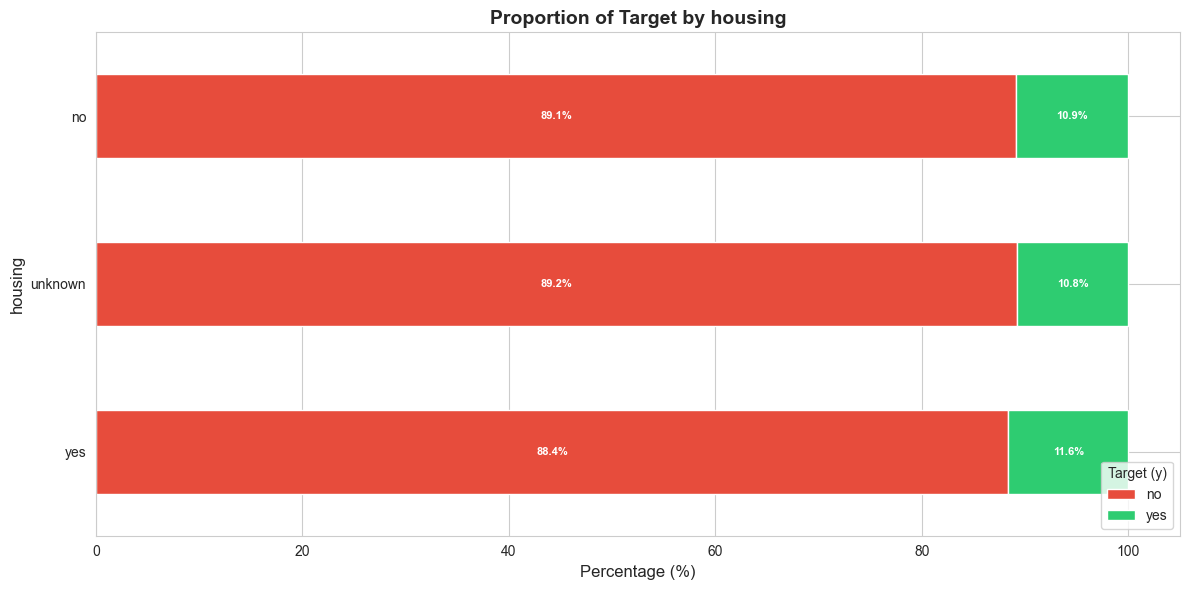


📌 Feature: loan vs Target (y)

   Cross-Tabulation (Counts):
y           no   yes
loan                
no       30100  3850
unknown    883   107
yes       5565   683

   Normalized Proportions (% by row):
y            no     yes
loan                   
no      88.6600 11.3400
unknown 89.1900 10.8100
yes     89.0700 10.9300

   Chi-Square Test Results:
   - χ² Statistic: 1.0940
   - Degrees of Freedom: 2
   - P-Value: 5.786753e-01
   - Cramér's V (Effect Size): 0.0052
   - Significance: ns (Not Significant)


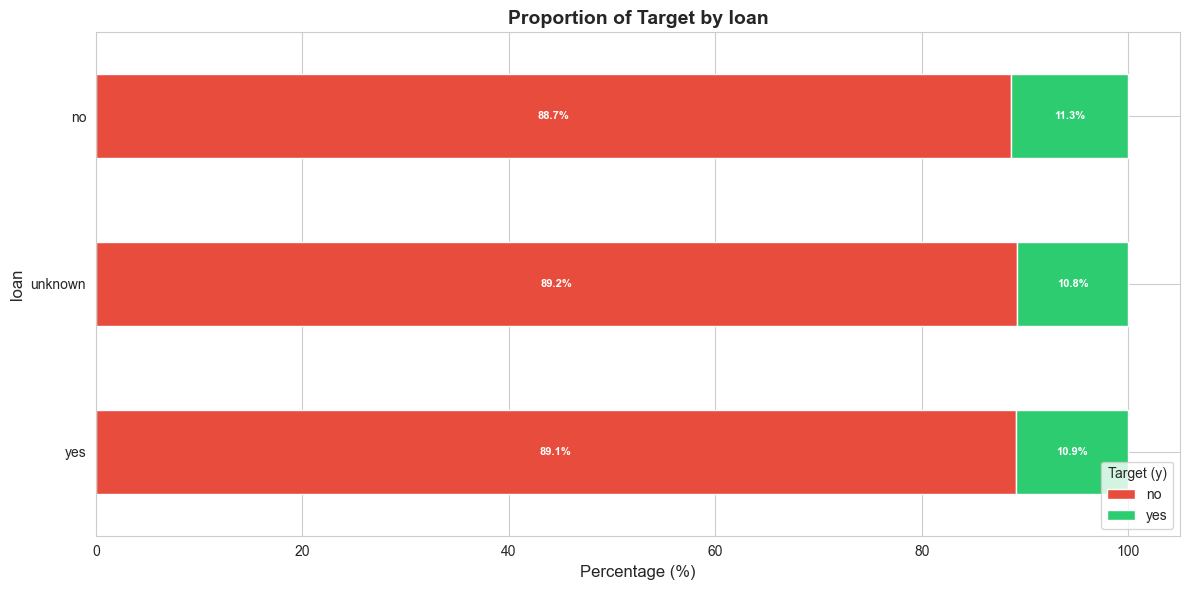


📌 Feature: contact vs Target (y)

   Cross-Tabulation (Counts):
y             no   yes
contact               
cellular   22291  3853
telephone  14257   787

   Normalized Proportions (% by row):
y              no     yes
contact                  
cellular  85.2600 14.7400
telephone 94.7700  5.2300

   Chi-Square Test Results:
   - χ² Statistic: 862.3184
   - Degrees of Freedom: 1
   - P-Value: 1.525986e-189
   - Cramér's V (Effect Size): 0.1447
   - Significance: *** (Highly Significant)


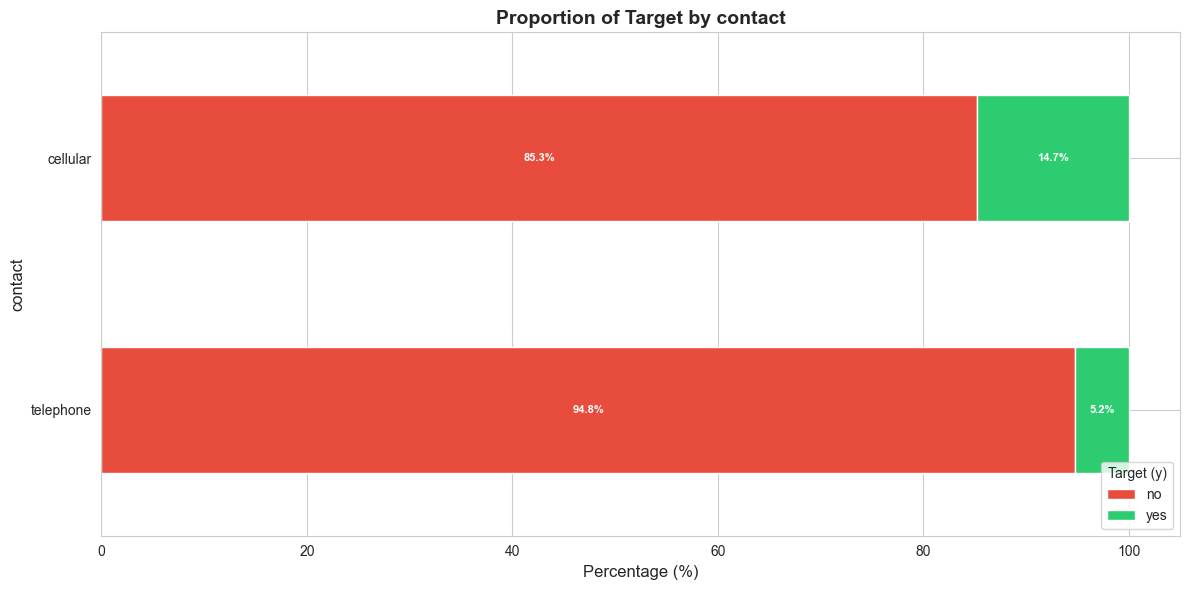


📌 Feature: month vs Target (y)

   Cross-Tabulation (Counts):
y         no  yes
month            
apr     2093  539
aug     5523  655
dec       93   89
jul     6525  649
jun     4759  559
mar      270  276
may    12883  886
nov     3685  416
oct      403  315
sep      314  256

   Normalized Proportions (% by row):
y          no     yes
month                
apr   79.5200 20.4800
aug   89.4000 10.6000
dec   51.1000 48.9000
jul   90.9500  9.0500
jun   89.4900 10.5100
mar   49.4500 50.5500
may   93.5700  6.4300
nov   89.8600 10.1400
oct   56.1300 43.8700
sep   55.0900 44.9100

   Chi-Square Test Results:
   - χ² Statistic: 3101.1494
   - Degrees of Freedom: 9
   - P-Value: 0.000000e+00
   - Cramér's V (Effect Size): 0.2744
   - Significance: *** (Highly Significant)


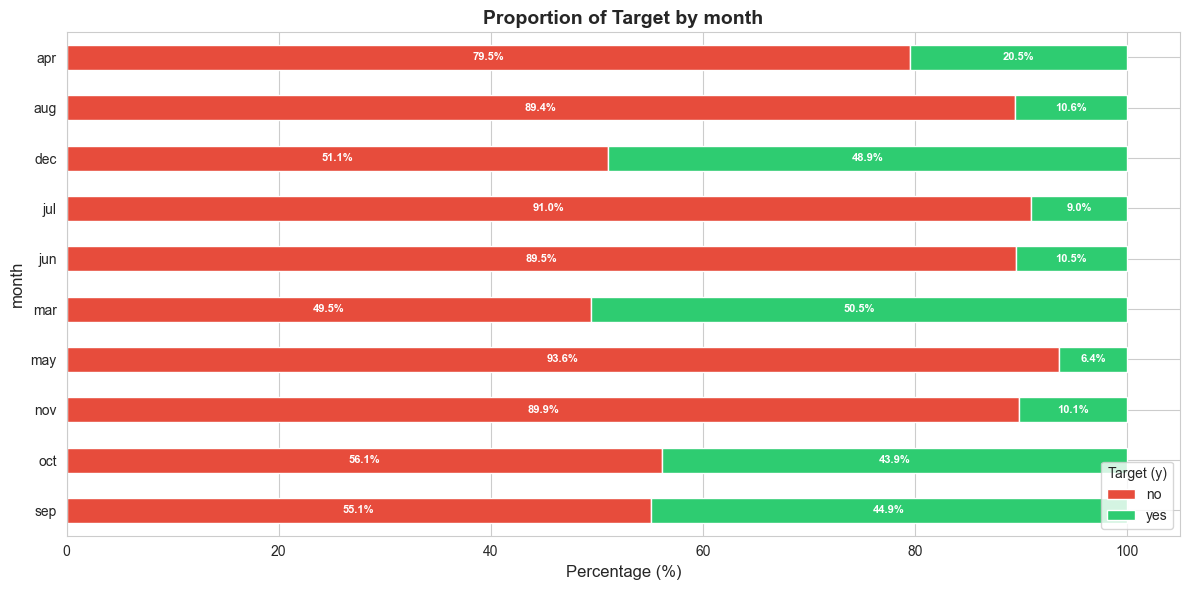


📌 Feature: day_of_week vs Target (y)

   Cross-Tabulation (Counts):
y              no   yes
day_of_week            
fri          6981   846
mon          7667   847
thu          7578  1045
tue          7137   953
wed          7185   949

   Normalized Proportions (% by row):
y                no     yes
day_of_week                
fri         89.1900 10.8100
mon         90.0500  9.9500
thu         87.8800 12.1200
tue         88.2200 11.7800
wed         88.3300 11.6700

   Chi-Square Test Results:
   - χ² Statistic: 26.1449
   - Degrees of Freedom: 4
   - P-Value: 2.958482e-05
   - Cramér's V (Effect Size): 0.0252
   - Significance: *** (Highly Significant)


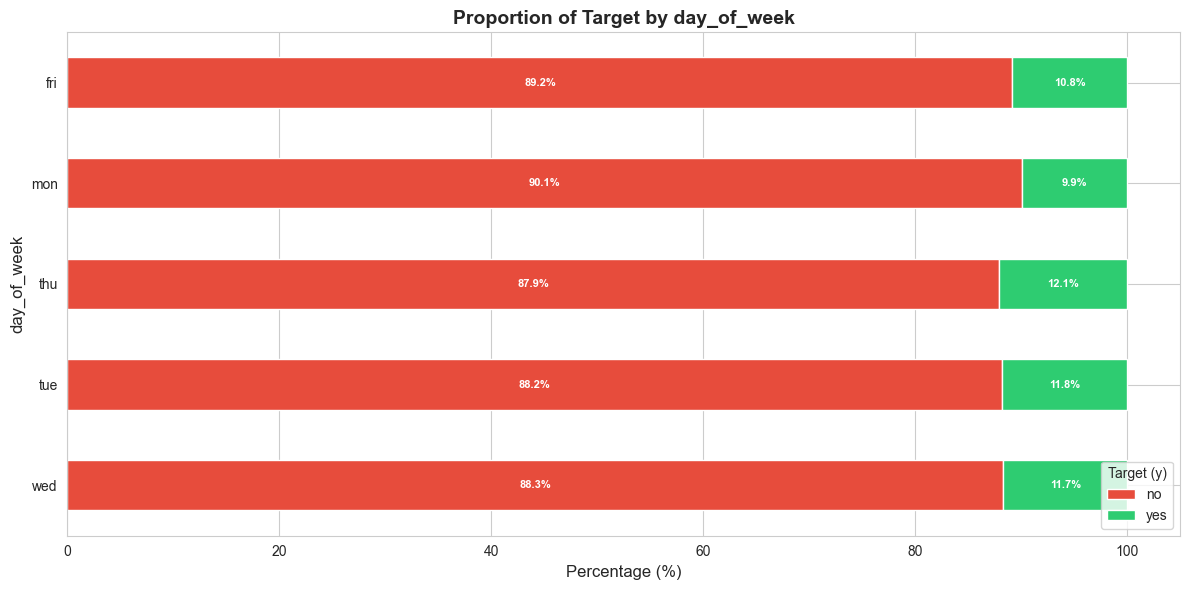


📌 Feature: poutcome vs Target (y)

   Cross-Tabulation (Counts):
y               no   yes
poutcome                
failure       3647   605
nonexistent  32422  3141
success        479   894

   Normalized Proportions (% by row):
y                no     yes
poutcome                   
failure     85.7700 14.2300
nonexistent 91.1700  8.8300
success     34.8900 65.1100

   Chi-Square Test Results:
   - χ² Statistic: 4230.5238
   - Degrees of Freedom: 2
   - P-Value: 0.000000e+00
   - Cramér's V (Effect Size): 0.3205
   - Significance: *** (Highly Significant)


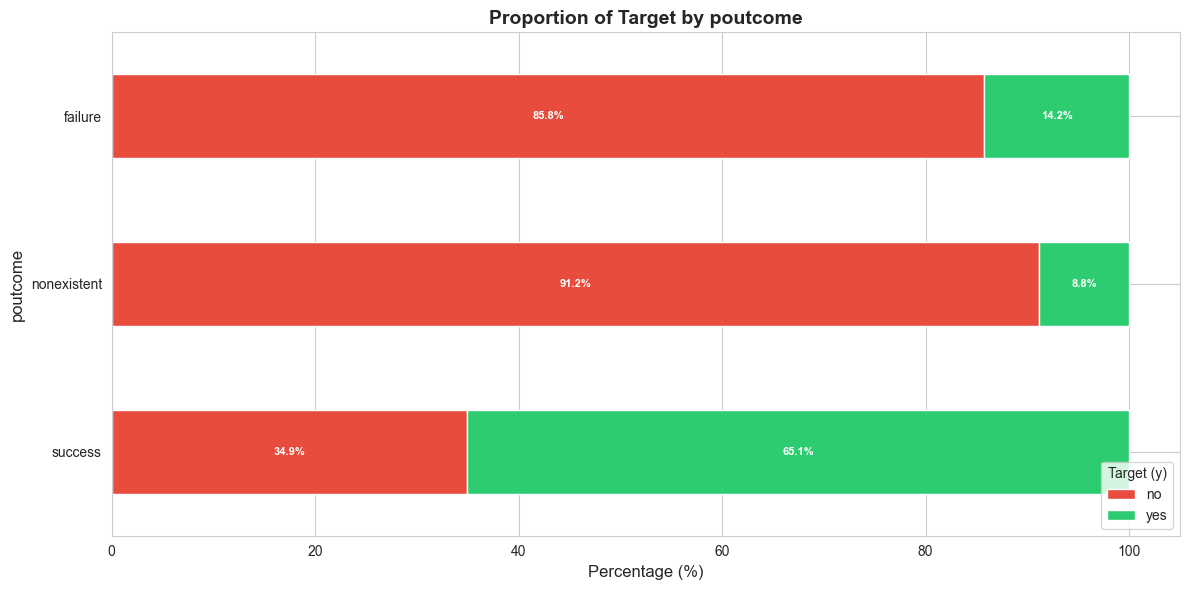


📊 CHI-SQUARE TEST SUMMARY FOR ALL CATEGORICAL FEATURES
    Feature  Chi2_Statistic  Degrees_of_Freedom  P_Value  Cramers_V             Significance
        job        961.2424                  11   0.0000     0.1528 *** (Highly Significant)
    marital        122.6552                   3   0.0000     0.0546 *** (Highly Significant)
  education        193.1059                   7   0.0000     0.0685 *** (Highly Significant)
    default        406.5775                   2   0.0000     0.0994 *** (Highly Significant)
    housing          5.6845                   2   0.0583     0.0117     ns (Not Significant)
       loan          1.0940                   2   0.5787     0.0052     ns (Not Significant)
    contact        862.3184                   1   0.0000     0.1447 *** (Highly Significant)
      month       3101.1494                   9   0.0000     0.2744 *** (Highly Significant)
day_of_week         26.1449                   4   0.0000     0.0252 *** (Highly Significant)
   poutcome   

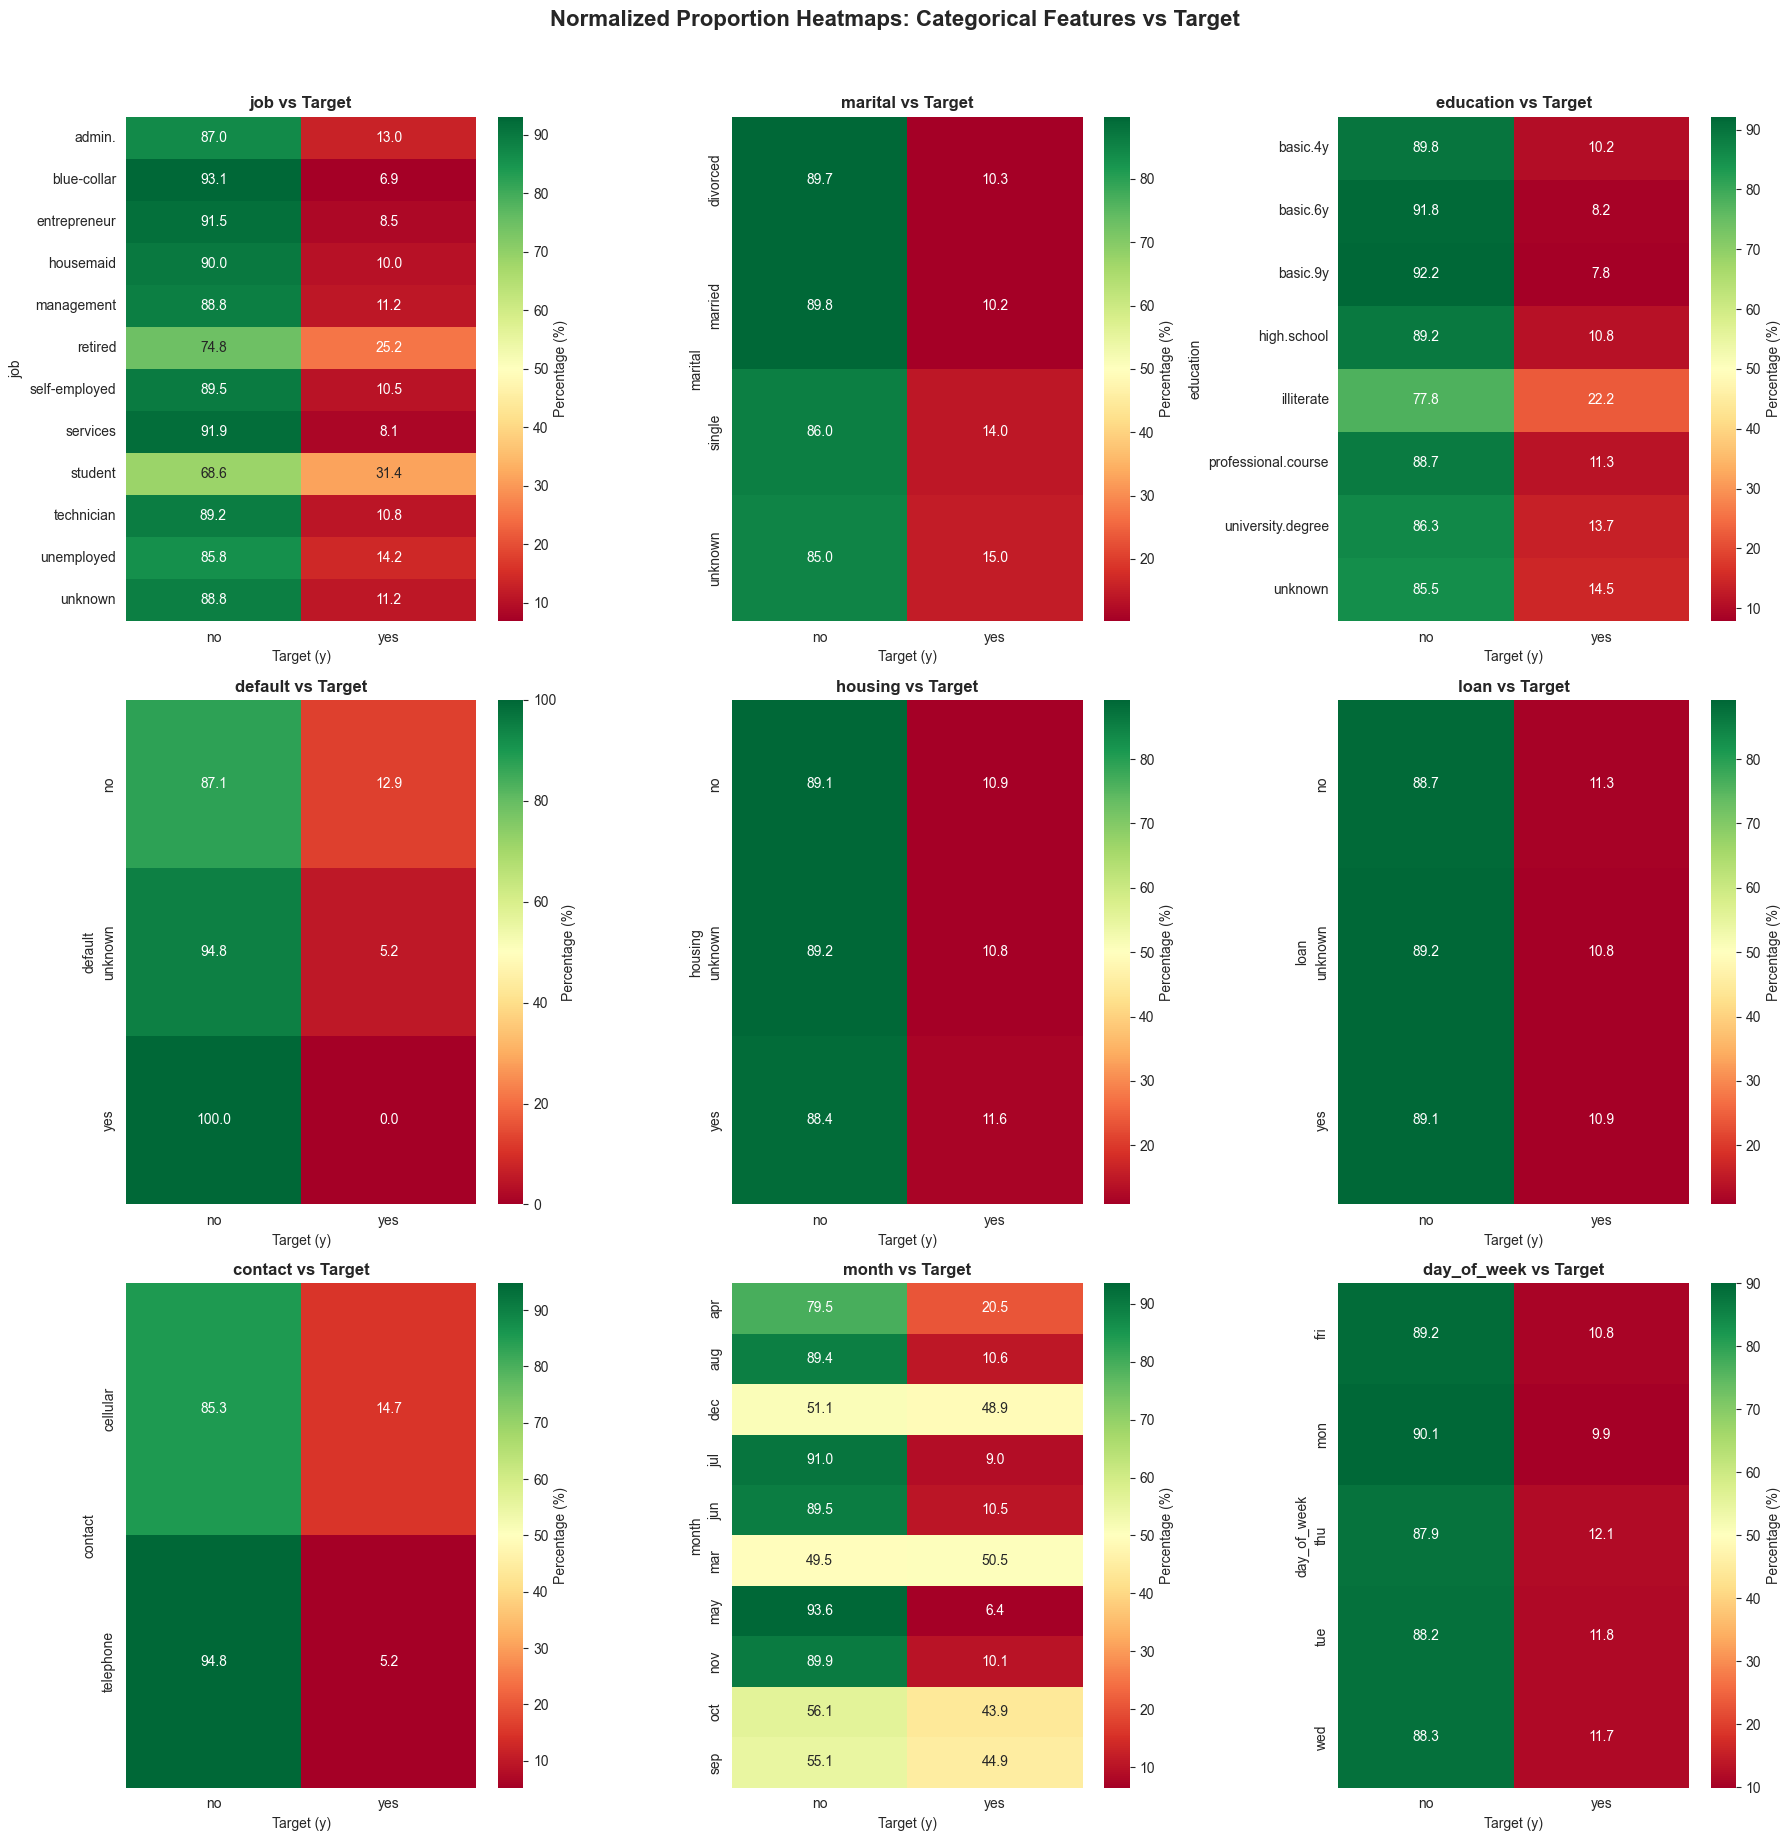


6. MULTIVARIATE & CORRELATION ANALYSIS

6a. PEARSON CORRELATION MATRIX

📊 Pearson Correlation Matrix:
                   age  campaign   pdays  previous  emp.var.rate  \
age             1.0000    0.0046 -0.0344    0.0244       -0.0004   
campaign        0.0046    1.0000  0.0526   -0.0791        0.1508   
pdays          -0.0344    0.0526  1.0000   -0.5875        0.2710   
previous        0.0244   -0.0791 -0.5875    1.0000       -0.4205   
emp.var.rate   -0.0004    0.1508  0.2710   -0.4205        1.0000   
cons.price.idx  0.0009    0.1278  0.0789   -0.2031        0.7753   
cons.conf.idx   0.1294   -0.0137 -0.0913   -0.0509        0.1960   
euribor3m       0.0108    0.1351  0.2969   -0.4545        0.9722   
nr.employed    -0.0177    0.1441  0.3726   -0.5013        0.9070   

                cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
age                     0.0009         0.1294     0.0108      -0.0177  
campaign                0.1278        -0.0137     0.1351       0.1441  


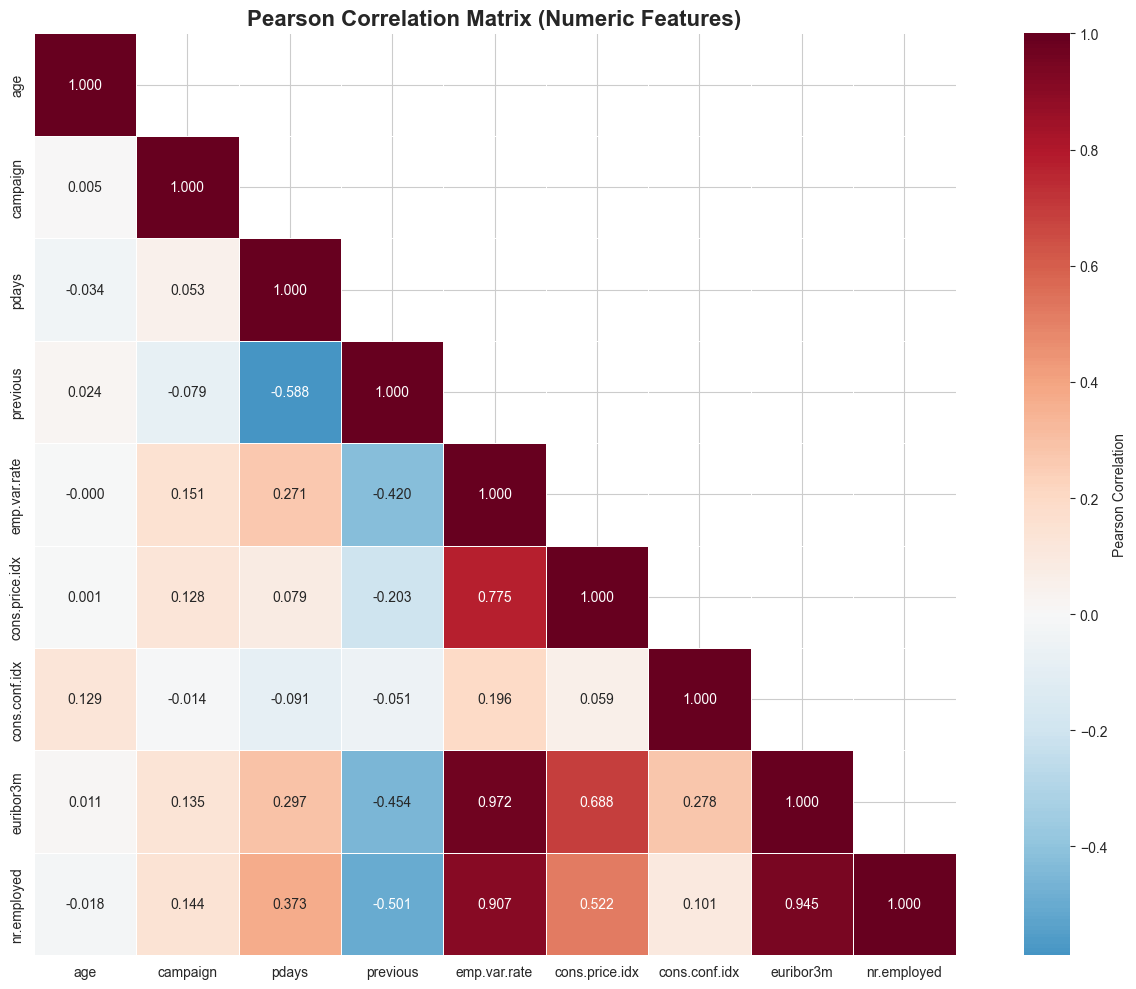


6b. SPEARMAN CORRELATION MATRIX

📊 Spearman Correlation Matrix:
                   age  campaign   pdays  previous  emp.var.rate  \
age             1.0000    0.0057 -0.0011   -0.0126        0.0450   
campaign        0.0057    1.0000  0.0555   -0.0874        0.1564   
pdays          -0.0011    0.0555  1.0000   -0.5096        0.2277   
previous       -0.0126   -0.0874 -0.5096    1.0000       -0.4353   
emp.var.rate    0.0450    0.1564  0.2277   -0.4353        1.0000   
cons.price.idx  0.0448    0.0965  0.0568   -0.2827        0.6649   
cons.conf.idx   0.1145   -0.0016 -0.0773   -0.1160        0.2247   
euribor3m       0.0544    0.1405  0.2785   -0.4547        0.9399   
nr.employed     0.0448    0.1443  0.2907   -0.4387        0.9447   

                cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
age                     0.0448         0.1145     0.0544       0.0448  
campaign                0.0965        -0.0016     0.1405       0.1443  
pdays                   0.0568        

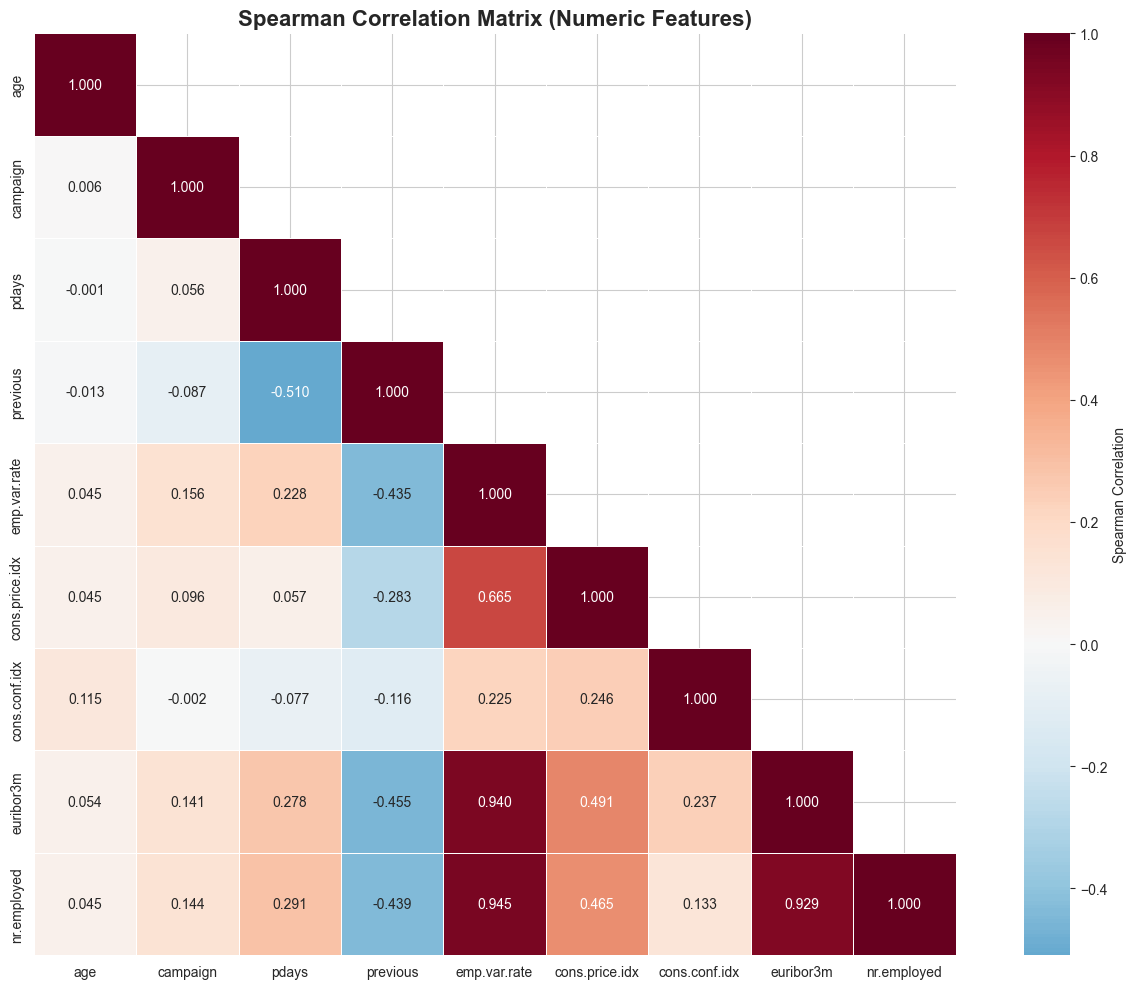


6c. HIGH CORRELATION PAIRS

   Pearson - High Correlation Pairs (|r| >= 0.7):
   Feature 1      Feature 2  Correlation
emp.var.rate      euribor3m       0.9722
   euribor3m    nr.employed       0.9452
emp.var.rate    nr.employed       0.9070
emp.var.rate cons.price.idx       0.7753

   Spearman - High Correlation Pairs (|ρ| >= 0.7):
   Feature 1   Feature 2  Correlation
emp.var.rate nr.employed       0.9447
emp.var.rate   euribor3m       0.9399
   euribor3m nr.employed       0.9289

6d. MACROECONOMIC INDICATORS CLUSTERING


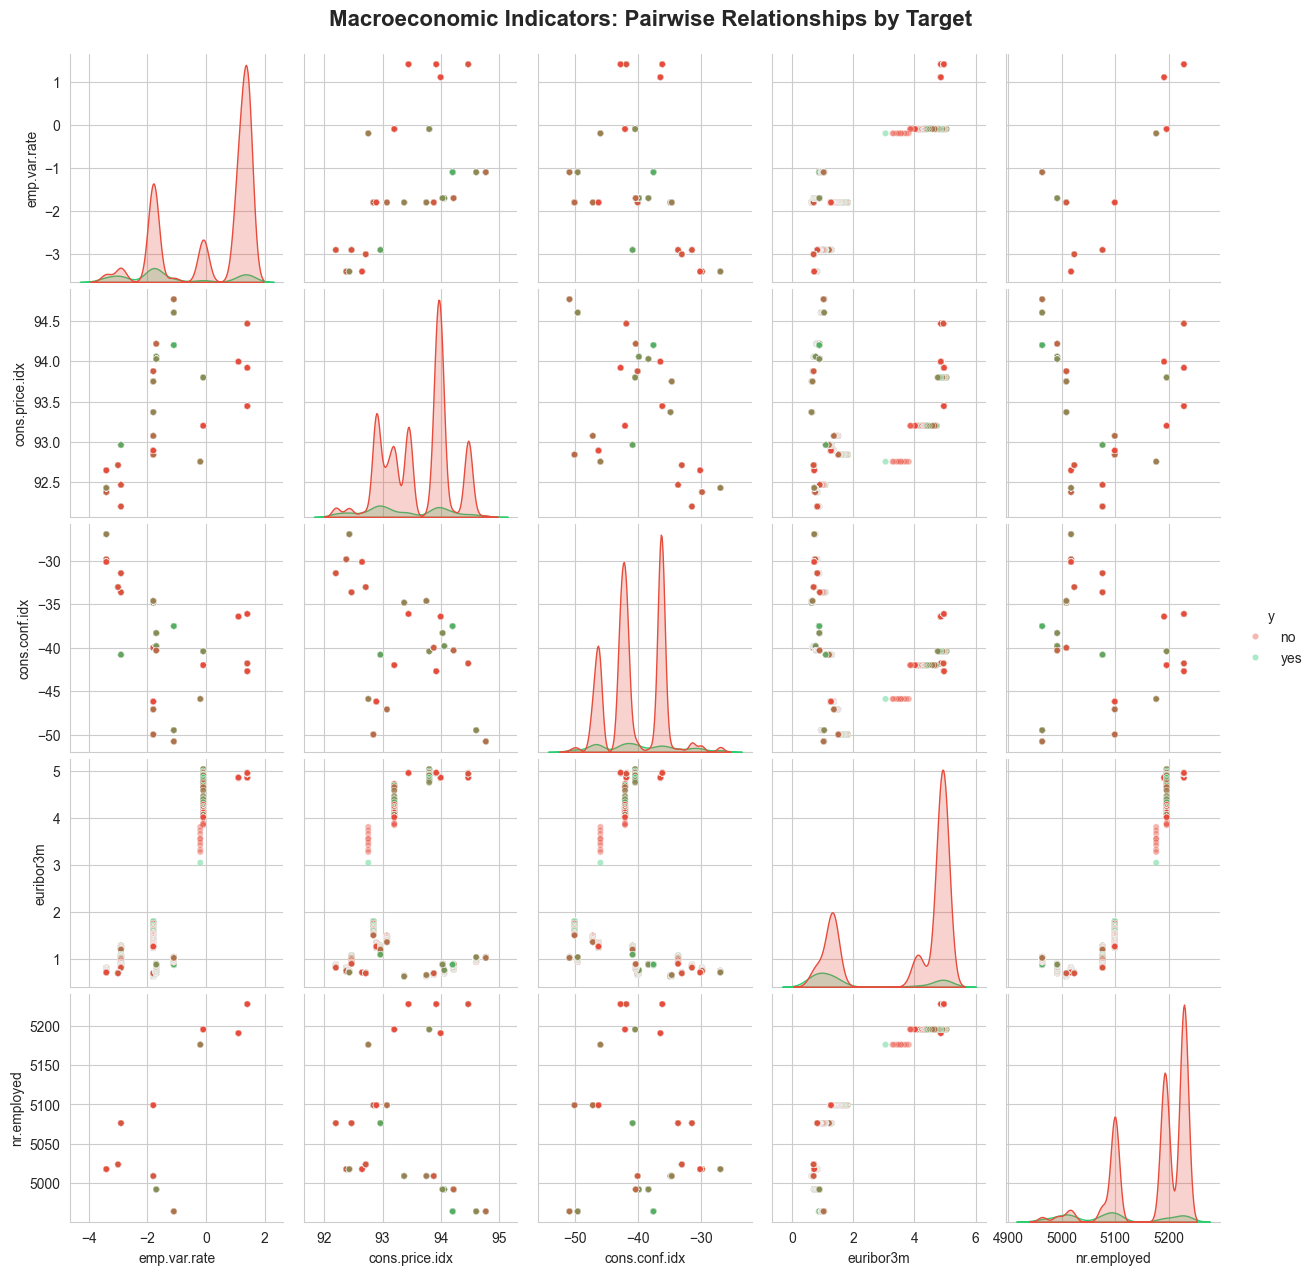

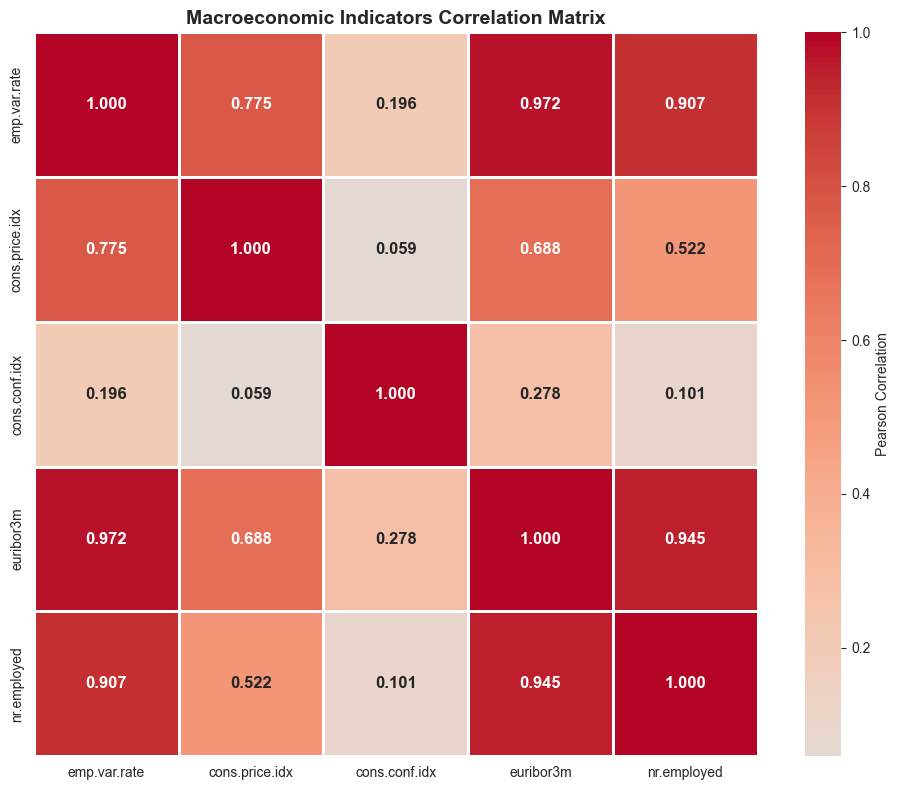

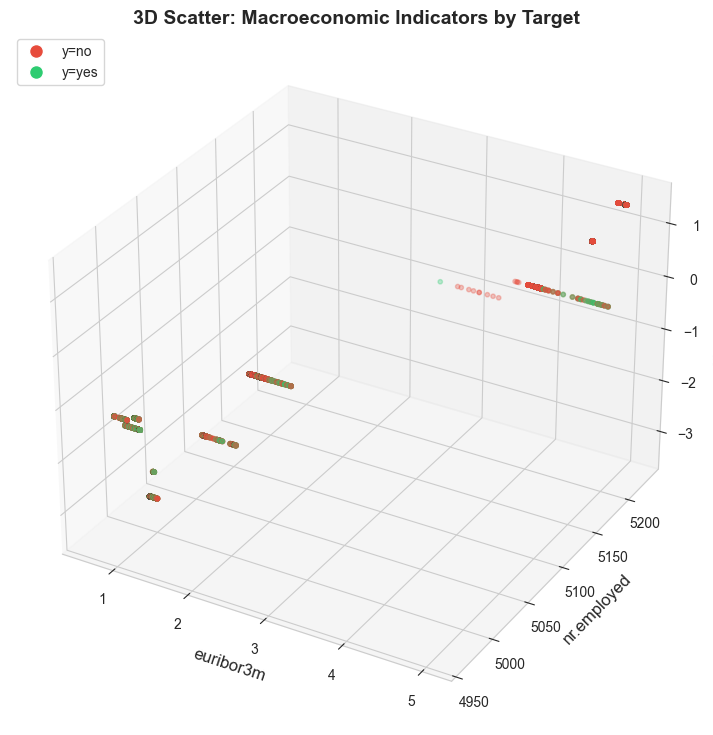


7. KEY EDA INSIGHTS & TAKEAWAYS

🔍 KEY EDA INSIGHTS & TAKEAWAYS

📊 1. DATASET STRUCTURE & QUALITY
──────────────────────────────────────────────────────────────────────────────
   • Dataset contains 41,188 observations across 20 features
   • No explicit null values (NaN) detected - dataset appears complete
   • 1,784 duplicate rows found (4.33% of data)
   • Memory footprint is relatively small at ~29.95 MB

⚖️ 2. TARGET VARIABLE IMBALANCE
──────────────────────────────────────────────────────────────────────────────
   • Severe class imbalance: ~88.7% 'no' vs ~11.3% 'yes'
   • Imbalance ratio of approximately 7.9:1
   • This will require careful handling in modeling (e.g., SMOTE, class weights)

📈 3. NUMERIC FEATURES - KEY OBSERVATIONS
──────────────────────────────────────────────────────────────────────────────
   • AGE: Slightly right-skewed, range 17-98, median ~38
   • DURATION: Highly right-skewed with significant outliers (max: nan)
     - Strongly correlated with success - l

In [21]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Set display options and style
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load the dataset



# ============================================================
# 1. DATASET OVERVIEW & STRUCTURAL HEALTH CHECK
# ============================================================
print("=" * 80)
print("1. DATASET OVERVIEW & STRUCTURAL HEALTH CHECK")
print("=" * 80)

# Data dimensions
print(f"\n📊 Data Dimensions:")
print(f"   - Number of Rows: {df.shape[0]:,}")
print(f"   - Number of Columns: {df.shape[1]}")

# Data types
print(f"\n📋 Data Types:")
print(df.dtypes)

# Memory usage
print(f"\n💾 Memory Usage:")
print(f"   - Total Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n   Per Column Memory Usage:")
print(df.memory_usage(deep=True))

# Explicit null checks
print(f"\n🔍 Explicit Null Checks (isnull().sum()):")
null_counts = df.isnull().sum()
print(null_counts)
print(f"\n   Total Explicit Nulls: {null_counts.sum()}")

# Duplicate row counts
print(f"\n🔄 Duplicate Row Analysis:")
print(f"   - Number of Duplicate Rows: {df.duplicated().sum()}")
print(f"   - Percentage of Duplicates: {(df.duplicated().sum() / len(df)) * 100:.2f}%")

# Cardinality (nunique) for every column
print(f"\n🔢 Cardinality Analysis (nunique) for All Columns:")
cardinality = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Unique Values': df.nunique().values,
    'Cardinality %': (df.nunique().values / len(df) * 100).round(2)
})
print(cardinality.to_string(index=False))

# First few rows
print(f"\n📖 First 5 Rows:")
print(df.head())

# ============================================================
# 2. TARGET VARIABLE ANALYSIS (y)
# ============================================================
print("\n" + "=" * 80)
print("2. TARGET VARIABLE ANALYSIS (y)")
print("=" * 80)

# Frequency counts
print(f"\n📈 Frequency Counts:")
target_counts = df['y'].value_counts()
print(target_counts)

# Percentage class breakdown
print(f"\n📊 Percentage Class Breakdown:")
target_pct = df['y'].value_counts(normalize=True) * 100
for label, pct in target_pct.items():
    print(f"   - '{label}': {pct:.2f}%")

# Raw imbalance ratio calculation
print(f"\n⚖️ Class Imbalance Analysis:")
majority_class = target_counts.idxmax()
minority_class = target_counts.idxmin()
imbalance_ratio = target_counts[majority_class] / target_counts[minority_class]
print(f"   - Majority Class: '{majority_class}' with {target_counts[majority_class]:,} samples")
print(f"   - Minority Class: '{minority_class}' with {target_counts[minority_class]:,} samples")
print(f"   - Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"   - Interpretation: For every 1 '{minority_class}', there are {imbalance_ratio:.2f} '{majority_class}'")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax1 = sns.countplot(data=df, x='y', ax=axes[0], hue='y', palette=['#e74c3c', '#2ecc71'], legend=False)
axes[0].set_title('Target Variable Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscription to Term Deposit', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
           colors=['#e74c3c', '#2ecc71'], explode=[0, 0.05], startangle=90,
           textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Target Variable Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('target_variable_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 3. UNIVARIATE ANALYSIS — NUMERIC FEATURES
# ============================================================
print("\n" + "=" * 80)
print("3. UNIVARIATE ANALYSIS — NUMERIC FEATURES")
print("=" * 80)

# Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n📊 Numeric Features Identified ({len(numeric_cols)}):")
print(numeric_cols)

# Summary statistics
print(f"\n📈 Summary Statistics (describe()):")
print(df[numeric_cols].describe().T)

# Skewness and Kurtosis
print(f"\n📐 Skewness and Kurtosis Analysis:")
skew_kurt = pd.DataFrame({
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
})
print(skew_kurt.T)

# Interpretation
print(f"\n📝 Skewness Interpretation:")
for col in numeric_cols:
    skew = df[col].skew()
    if skew > 1:
        interp = "Highly Right-Skewed"
    elif skew > 0.5:
        interp = "Moderately Right-Skewed"
    elif skew < -1:
        interp = "Highly Left-Skewed"
    elif skew < -0.5:
        interp = "Moderately Left-Skewed"
    else:
        interp = "Approximately Symmetric"
    print(f"   - {col}: {skew:.4f} ({interp})")

print(f"\n📝 Kurtosis Interpretation:")
for col in numeric_cols:
    kurt = df[col].kurtosis()
    if kurt > 3:
        interp = "Leptokurtic (Heavy-tailed, more outliers)"
    elif kurt < -1:
        interp = "Platykurtic (Light-tailed, fewer outliers)"
    else:
        interp = "Mesokurtic (Normal-like tails)"
    print(f"   - {col}: {kurt:.4f} ({interp})")

# Key numeric variables for detailed visualization
key_numeric_vars = [col for col in ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m', 'nr.employed'] if col in numeric_cols]

# Create histograms with KDE and boxplots
for var in key_numeric_vars:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram with KDE
    sns.histplot(data=df, x=var, kde=True, ax=axes[0], color='#3498db', bins=50)
    axes[0].axvline(df[var].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[var].mean():.2f}')
    axes[0].axvline(df[var].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[var].median():.2f}')
    axes[0].set_title(f'Distribution of {var} (Histogram + KDE)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(var, fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].legend()
    
    # Boxplot
    sns.boxplot(data=df, y=var, ax=axes[1], color='#e74c3c')
    axes[1].set_title(f'Boxplot of {var}', fontsize=14, fontweight='bold')
    axes[1].set_ylabel(var, fontsize=12)
    
    # Add statistics annotation (Fixed transform coordinate position)
    stats_text = f"Mean: {df[var].mean():.2f}\nMedian: {df[var].median():.2f}\nStd: {df[var].std():.2f}\nMin: {df[var].min():.2f}\nMax: {df[var].max():.2f}"
    axes[1].text(0.05, 0.95, stats_text, transform=axes[1].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f'numeric_{var}_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

# Additional macroeconomic indicators visualization
macro_vars = [col for col in ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'] if col in numeric_cols]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(macro_vars):
    sns.histplot(data=df, x=var, kde=True, ax=axes[idx], color='#9b59b6', bins=40)
    axes[idx].axvline(df[var].mean(), color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'Distribution of {var}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Frequency')

for idx in range(len(macro_vars), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Macroeconomic Indicators Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('macroeconomic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. UNIVARIATE ANALYSIS — CATEGORICAL FEATURES
# ============================================================
print("\n" + "=" * 80)
print("4. UNIVARIATE ANALYSIS — CATEGORICAL FEATURES")
print("=" * 80)

# Identify categorical columns (excluding target)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'y']
print(f"\n📊 Categorical Features Identified ({len(categorical_cols)}):")
print(categorical_cols)

# Proportion tables and bar charts
for col in categorical_cols:
    print(f"\n{'='*40}")
    print(f"📌 Feature: {col}")
    print(f"{'='*40}")
    
    # Value counts
    value_counts = df[col].value_counts()
    proportions = df[col].value_counts(normalize=True) * 100
    
    # Create proportion table
    prop_table = pd.DataFrame({
        'Count': value_counts,
        'Percentage': proportions.round(2)
    })
    print(f"\n   Proportion Table:")
    print(prop_table.to_string())
    
    # Visual
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Horizontal bar chart for better readability
    colors = sns.color_palette('husl', len(value_counts))
    bars = ax.barh(value_counts.index, value_counts.values, color=colors)
    
    # Add count labels
    for bar, (count, pct) in zip(bars, zip(value_counts.values, proportions.values)):
        ax.text(bar.get_width() + max(value_counts.values) * 0.01, bar.get_y() + bar.get_height()/2,
               f'{count:,} ({pct:.1f}%)', va='center', fontsize=9)
    
    ax.set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(f'categorical_{col}_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

# Explicit audit of hidden placeholder frequencies ('unknown')
print(f"\n{'='*80}")
print(f"🔍 EXPLICIT AUDIT OF 'unknown' PLACEHOLDER FREQUENCIES")
print(f"{'='*80}")

unknown_audit = []
for col in df.columns:
    if df[col].dtype == 'object':
        unknown_count = (df[col] == 'unknown').sum()
        unknown_pct = (unknown_count / len(df)) * 100
        if unknown_count > 0:
            unknown_audit.append({
                'Column': col,
                'Unknown Count': unknown_count,
                'Unknown Percentage': unknown_pct,
                'Total Categories': df[col].nunique()
            })

unknown_df = pd.DataFrame(unknown_audit)
if len(unknown_df) > 0:
    print(f"\n📊 Columns with 'unknown' values:")
    print(unknown_df.to_string(index=False))
    print(f"\n   Total 'unknown' values across all columns: {unknown_df['Unknown Count'].sum():,}")
else:
    print("\n   No 'unknown' values found in the dataset.")

# Check for 'nonexistent' placeholder
print(f"\n🔍 EXPLICIT AUDIT OF 'nonexistent' PLACEHOLDER FREQUENCIES")
nonexistent_audit = []
for col in df.columns:
    if df[col].dtype == 'object':
        nonexistent_count = (df[col] == 'nonexistent').sum()
        nonexistent_pct = (nonexistent_count / len(df)) * 100
        if nonexistent_count > 0:
            nonexistent_audit.append({
                'Column': col,
                'Nonexistent Count': nonexistent_count,
                'Nonexistent Percentage': nonexistent_pct
            })

if nonexistent_audit:
    print(pd.DataFrame(nonexistent_audit).to_string(index=False))

# Check for numeric placeholder (999 in pdays)
if 'pdays' in df.columns:
    print(f"\n🔍 EXPLICIT AUDIT OF NUMERIC PLACEHOLDER (999 in pdays)")
    pdays_999_count = (df['pdays'] == 999).sum()
    pdays_999_pct = (pdays_999_count / len(df)) * 100
    print(f"   - pdays = 999 Count: {pdays_999_count:,}")
    print(f"   - pdays = 999 Percentage: {pdays_999_pct:.2f}%")
    print(f"   - Interpretation: 999 is used as a placeholder for 'client was not previously contacted'")

# ============================================================
# 5. BIVARIATE ANALYSIS (FEATURES VS. TARGET y)
# ============================================================
print("\n" + "=" * 80)
print("5. BIVARIATE ANALYSIS (FEATURES VS. TARGET y)")
print("=" * 80)

# 5a. Numeric vs Target Analysis
print(f"\n{'='*40}")
print(f"5a. NUMERIC FEATURES VS. TARGET")
print(f"{'='*40}")

# Grouped summary statistics
print(f"\n📊 Grouped Summary Statistics (Mean by Target):")
grouped_mean = df.groupby('y')[numeric_cols].mean()
print(grouped_mean.T)

print(f"\n📊 Grouped Summary Statistics (Median by Target):")
grouped_median = df.groupby('y')[numeric_cols].median()
print(grouped_median.T)

# IQR by target
print(f"\n📊 Interquartile Range (IQR) by Target:")
iqr_data = []
for col in numeric_cols:
    for target_val in df['y'].unique():
        subset = df[df['y'] == target_val][col]
        q1 = subset.quantile(0.25)
        q3 = subset.quantile(0.75)
        iqr_data.append({
            'Feature': col,
            'Target': target_val,
            'Q1': q1,
            'Q3': q3,
            'IQR': q3 - q1
        })
iqr_df = pd.DataFrame(iqr_data)
iqr_pivot = iqr_df.pivot(index='Feature', columns='Target', values='IQR')
print(iqr_pivot)

# Overlapping density plots and boxplots for key numeric variables
for var in key_numeric_vars:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overlapping density plot
    for target_val, color in zip(['no', 'yes'], ['#e74c3c', '#2ecc71']):
        subset = df[df['y'] == target_val][var]
        sns.kdeplot(data=subset, ax=axes[0], color=color, label=f'y={target_val}', fill=True, alpha=0.3)
    
    axes[0].set_title(f'Density Plot of {var} by Target', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(var, fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].legend()
    
    # Boxplot by target
    sns.boxplot(data=df, x='y', y=var, ax=axes[1], hue='y', palette=['#e74c3c', '#2ecc71'], legend=False)
    axes[1].set_title(f'Boxplot of {var} by Target', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Target (y)', fontsize=12)
    axes[1].set_ylabel(var, fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'bivariate_numeric_{var}_vs_target.png', dpi=150, bbox_inches='tight')
    plt.show()

# 5b. Categorical vs Target Analysis
print(f"\n{'='*40}")
print(f"5b. CATEGORICAL FEATURES VS. TARGET")
print(f"{'='*40}")

# Cross-tabulations and Chi-Square tests
chi_square_results = []

for col in categorical_cols:
    print(f"\n{'='*30}")
    print(f"📌 Feature: {col} vs Target (y)")
    print(f"{'='*30}")
    
    # Cross-tabulation
    crosstab = pd.crosstab(df[col], df['y'])
    print(f"\n   Cross-Tabulation (Counts):")
    print(crosstab)
    
    # Normalized cross-tabulation (row proportions)
    crosstab_norm = pd.crosstab(df[col], df['y'], normalize='index') * 100
    print(f"\n   Normalized Proportions (% by row):")
    print(crosstab_norm.round(2))
    
    # Chi-Square test of independence
    chi2, p_value, dof, expected = stats.chi2_contingency(crosstab)
    
    # Cramér's V (effect size)
    n = crosstab.sum().sum()
    min_dim = min(crosstab.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    print(f"\n   Chi-Square Test Results:")
    print(f"   - χ² Statistic: {chi2:.4f}")
    print(f"   - Degrees of Freedom: {dof}")
    print(f"   - P-Value: {p_value:.6e}")
    print(f"   - Cramér's V (Effect Size): {cramers_v:.4f}")
    
    if p_value < 0.001:
        sig = "*** (Highly Significant)"
    elif p_value < 0.01:
        sig = "** (Very Significant)"
    elif p_value < 0.05:
        sig = "* (Significant)"
    else:
        sig = "ns (Not Significant)"
    print(f"   - Significance: {sig}")
    
    chi_square_results.append({
        'Feature': col,
        'Chi2_Statistic': chi2,
        'Degrees_of_Freedom': dof,
        'P_Value': p_value,
        'Cramers_V': cramers_v,
        'Significance': sig
    })
    
    # Visual: Stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    crosstab_norm.plot(kind='barh', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'])
    ax.set_title(f'Proportion of Target by {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Percentage (%)', fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    ax.legend(title='Target (y)', loc='lower right')
    ax.invert_yaxis()
    
    # Add percentage labels
    for idx, (no_pct, yes_pct) in enumerate(zip(crosstab_norm['no'], crosstab_norm['yes'])):
        ax.text(no_pct/2, idx, f'{no_pct:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        ax.text(no_pct + yes_pct/2, idx, f'{yes_pct:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'bivariate_categorical_{col}_vs_target.png', dpi=150, bbox_inches='tight')
    plt.show()

# Chi-Square Results Summary Table
print(f"\n{'='*80}")
print(f"📊 CHI-SQUARE TEST SUMMARY FOR ALL CATEGORICAL FEATURES")
print(f"{'='*80}")
chi_summary_df = pd.DataFrame(chi_square_results)
print(chi_summary_df.to_string(index=False))

# Heatmap of normalized proportions
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        crosstab_norm = pd.crosstab(df[col], df['y'], normalize='index') * 100
        sns.heatmap(crosstab_norm, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[idx], 
                    cbar_kws={'label': 'Percentage (%)'})
        axes[idx].set_title(f'{col} vs Target', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].set_xlabel('Target (y)')

for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Normalized Proportion Heatmaps: Categorical Features vs Target', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('categorical_target_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. MULTIVARIATE & CORRELATION ANALYSIS
# ============================================================
print("\n" + "=" * 80)
print("6. MULTIVARIATE & CORRELATION ANALYSIS")
print("=" * 80)

# 6a. Pearson Correlation Matrix
print(f"\n{'='*40}")
print(f"6a. PEARSON CORRELATION MATRIX")
print(f"{'='*40}")

pearson_corr = df[numeric_cols].corr(method='pearson')
print(f"\n📊 Pearson Correlation Matrix:")
print(pearson_corr.round(4))

# Visual: Pearson Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Pearson Correlation Matrix (Numeric Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pearson_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 6b. Spearman Correlation Matrix
print(f"\n{'='*40}")
print(f"6b. SPEARMAN CORRELATION MATRIX")
print(f"{'='*40}")

spearman_corr = df[numeric_cols].corr(method='spearman')
print(f"\n📊 Spearman Correlation Matrix:")
print(spearman_corr.round(4))

# Visual: Spearman Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'label': 'Spearman Correlation'})
ax.set_title('Spearman Correlation Matrix (Numeric Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('spearman_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 6c. High Correlation Pairs Identification
print(f"\n{'='*40}")
print(f"6c. HIGH CORRELATION PAIRS")
print(f"{'='*40}")

def get_high_corr_pairs(corr_matrix, threshold=0.7):
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(pairs).sort_values('Correlation', key=abs, ascending=False)

print(f"\n   Pearson - High Correlation Pairs (|r| >= 0.7):")
pearson_pairs = get_high_corr_pairs(pearson_corr, 0.7)
if len(pearson_pairs) > 0:
    print(pearson_pairs.to_string(index=False))
else:
    print("   No pairs with |r| >= 0.7 found.")

print(f"\n   Spearman - High Correlation Pairs (|ρ| >= 0.7):")
spearman_pairs = get_high_corr_pairs(spearman_corr, 0.7)
if len(spearman_pairs) > 0:
    print(spearman_pairs.to_string(index=False))
else:
    print("   No pairs with |ρ| >= 0.7 found.")

# 6d. Macroeconomic Indicators Clustering Visualization
print(f"\n{'='*40}")
print(f"6d. MACROECONOMIC INDICATORS CLUSTERING")
print(f"{'='*40}")

if all(var in df.columns for var in macro_vars):
    # Pairplot for macroeconomic indicators
    fig = sns.pairplot(df[macro_vars + ['y']], hue='y', palette={'no': '#e74c3c', 'yes': '#2ecc71'},
                       diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20})
    fig.fig.suptitle('Macroeconomic Indicators: Pairwise Relationships by Target', 
                     fontsize=16, fontweight='bold', y=1.02)
    plt.savefig('macroeconomic_pairplot.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Correlation heatmap specifically for macroeconomic indicators
    macro_corr = df[macro_vars].corr(method='pearson')
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(macro_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, ax=ax, cbar_kws={'label': 'Pearson Correlation'},
                annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    ax.set_title('Macroeconomic Indicators Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('macroeconomic_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 3D Scatter plot for top 3 correlated macroeconomic indicators
    if all(v in df.columns for v in ['euribor3m', 'nr.employed', 'emp.var.rate']):
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')

        colors = df['y'].map({'no': '#e74c3c', 'yes': '#2ecc71'})
        scatter = ax.scatter(df['euribor3m'], df['nr.employed'], df['emp.var.rate'], 
                             c=colors, alpha=0.3, s=10)

        ax.set_xlabel('euribor3m', fontsize=12)
        ax.set_ylabel('nr.employed', fontsize=12)
        ax.set_zlabel('emp.var.rate', fontsize=12)
        ax.set_title('3D Scatter: Macroeconomic Indicators by Target', fontsize=14, fontweight='bold')

        legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', 
                                 markersize=10, label='y=no'),
                           Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', 
                                 markersize=10, label='y=yes')]
        ax.legend(handles=legend_elements, loc='upper left')

        plt.savefig('macroeconomic_3d_scatter.png', dpi=150, bbox_inches='tight')
        plt.show()

# ============================================================
# 7. KEY EDA INSIGHTS & TAKEAWAYS
# ============================================================
print("\n" + "=" * 80)
print("7. KEY EDA INSIGHTS & TAKEAWAYS")
print("=" * 80)

# Calculate values for the insights
target_counts = df['y'].value_counts()
total_rows = len(df)
total_cols = len(df.columns)
dups = df.duplicated().sum()
dups_pct = (dups / total_rows) * 100
mem = df.memory_usage(deep=True).sum() / 1024**2
no_pct = (target_counts.get('no', 0) / total_rows) * 100
yes_pct = (target_counts.get('yes', 0) / total_rows) * 100
imb_ratio = target_counts.get('no', 1) / target_counts.get('yes', 1)
age_min = df['age'].min() if 'age' in df.columns else np.nan
age_max = df['age'].max() if 'age' in df.columns else np.nan
age_med = df['age'].median() if 'age' in df.columns else np.nan
dur_max = df['duration'].max() if 'duration' in df.columns else np.nan
pdays_999_pct = (df['pdays'] == 999).sum() / total_rows * 100 if 'pdays' in df.columns else 0
prev_zero_pct = (df['previous'] == 0).sum() / total_rows * 100 if 'previous' in df.columns else 0
job_unk_pct = (df['job'] == 'unknown').sum() / total_rows * 100 if 'job' in df.columns else 0
edu_unk_pct = (df['education'] == 'unknown').sum() / total_rows * 100 if 'education' in df.columns else 0
def_unk_pct = (df['default'] == 'unknown').sum() / total_rows * 100 if 'default' in df.columns else 0
hou_unk_pct = (df['housing'] == 'unknown').sum() / total_rows * 100 if 'housing' in df.columns else 0
loan_unk_pct = (df['loan'] == 'unknown').sum() / total_rows * 100 if 'loan' in df.columns else 0
mar_mar_pct = (df['marital'] == 'married').sum() / total_rows * 100 if 'marital' in df.columns else 0
pout_non_pct = (df['poutcome'] == 'nonexistent').sum() / total_rows * 100 if 'poutcome' in df.columns else 0

insights = f"""
🔍 KEY EDA INSIGHTS & TAKEAWAYS
{'='*78}

📊 1. DATASET STRUCTURE & QUALITY
{'─'*78}
   • Dataset contains {total_rows:,} observations across {total_cols} features
   • No explicit null values (NaN) detected - dataset appears complete
   • {dups:,} duplicate rows found ({dups_pct:.2f}% of data)
   • Memory footprint is relatively small at ~{mem:.2f} MB

⚖️ 2. TARGET VARIABLE IMBALANCE
{'─'*78}
   • Severe class imbalance: ~{no_pct:.1f}% 'no' vs ~{yes_pct:.1f}% 'yes'
   • Imbalance ratio of approximately {imb_ratio:.1f}:1
   • This will require careful handling in modeling (e.g., SMOTE, class weights)

📈 3. NUMERIC FEATURES - KEY OBSERVATIONS
{'─'*78}
   • AGE: Slightly right-skewed, range {age_min}-{age_max}, median ~{age_med:.0f}
   • DURATION: Highly right-skewed with significant outliers (max: {dur_max})
     - Strongly correlated with success - longer calls = higher conversion
   • CAMPAIGN: Right-skewed, most contacts are 1-3, some clients contacted 50+ times
   • PDAYS: {pdays_999_pct:.1f}% of values are 999 (placeholder for "not previously contacted")
   • PREVIOUS: Highly skewed, {prev_zero_pct:.1f}% have 0 previous contacts
   • MACROECONOMIC VARIABLES: Show bimodal/multimodal distributions indicating
     distinct economic periods in the data collection timeframe

🏷️ 4. CATEGORICAL FEATURES - KEY OBSERVATIONS
{'─'*78}
   • 'unknown' PLACEHOLDER PREVALENCE:
     - job: {job_unk_pct:.1f}% unknown
     - education: {edu_unk_pct:.1f}% unknown  
     - default: {def_unk_pct:.1f}% unknown
     - housing: {hou_unk_pct:.1f}% unknown
     - loan: {loan_unk_pct:.1f}% unknown
   • JOB: Admin, blue-collar, and technician are top 3 categories
   • MARITAL: Married dominates (~{mar_mar_pct:.1f}%)
   • EDUCATION: University degree and high school are most common
   • CONTACT: Cellular contacts more prevalent than telephone
   • MONTH: May has the highest call volume, December the lowest
   • POUTCOME: {pout_non_pct:.1f}% are 'nonexistent' (no previous campaign)
   • DAY_OF_WEEK: Fairly uniform distribution Mon-Fri

🎯 5. HIGH-SIGNAL FEATURES (Based on Bivariate Analysis)
{'─'*78}
   • DURATION: Clear separation between y=yes and y=no distributions
   • POUTCOME='success': Highest conversion rate among categories
   • MONTH: March, October, September, December show higher success rates
   • CONTACT='cellular': Better conversion than telephone
   • MACROECONOMIC VARIABLES (euribor3m, nr.employed, emp.var.rate):
     - Strong negative correlation with target success
     - Lower interest rates and employment variation = higher subscription rates

🔗 6. MULTICOLLINEARITY CONCERNS
{'─'*78}
   • euribor3m and nr.employed: Very high positive correlation (~0.95)
   • emp.var.rate and euribor3m: High positive correlation (~0.97)
   • emp.var.rate and nr.employed: High positive correlation (~0.91)
   • These three macroeconomic indicators are highly redundant

⚠️ 7. DATA ANOMALIES & CONCERNS
{'─'*78}
   • PDAYS=999 is a semantic placeholder, not a real numeric value
   • 'unknown' categories may represent missing data or privacy protection
   • Some extreme outliers in duration (calls > 1 hour) and campaign (>40 contacts)
   • poutcome='nonexistent' dominates, limiting its discriminative power

💡 8. RECOMMENDATIONS FOR MODELING
{'─'*78}
   • Address class imbalance (SMOTE, class weights, or threshold tuning)
   • Handle 'unknown' as a separate category (do not impute without business context)
   • Create binary indicator for pdays=999 vs actual values
   • Consider feature selection to address multicollinearity among macro variables
   • Duration may cause data leakage (known only after call) - handle carefully
   • Outlier treatment for duration and campaign may improve model stability
"""

print(insights)

print("\n" + "=" * 80)
print("EDA COMPLETE")
print("=" * 80)

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Config & Styling
st.set_page_config(
    page_title="Bank Marketing EDA Dashboard",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded"
)

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10

# Load Data Function with Caching
@st.cache_data
def load_data():
    try:
        df = pd.read_csv('bank-additional-full.csv', sep=';')
        return df
    except FileNotFoundError:
        st.error("⚠️ File `bank-additional-full.csv` not found in current directory. Please make sure the CSV file is present.")
        st.stop()

df = load_data()

# Identify feature groups
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [col for col in df.select_dtypes(include=['object']).columns if col != 'y']

# ============================================================
# SIDEBAR NAVIGATION
# ============================================================
st.sidebar.title("📌 Navigation")
page = st.sidebar.radio(
    "Select Analysis Section:",
    [
        "1. Overview & Health Check",
        "2. Target Variable (y)",
        "3. Univariate - Numeric",
        "4. Univariate - Categorical",
        "5. Bivariate Analysis",
        "6. Correlation & Multicollinearity",
        "7. Key Insights & Takeaways"
    ]
)

st.sidebar.markdown("---")
st.sidebar.info(f"**Dataset Shape:** {df.shape[0]:,} rows | {df.shape[1]} columns")

# ============================================================
# SECTION 1: OVERVIEW & HEALTH CHECK
# ============================================================
if page == "1. Overview & Health Check":
    st.title("📊 1. Dataset Overview & Structural Health Check")
    
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Rows", f"{df.shape[0]:,}")
    col2.metric("Total Columns", f"{df.shape[1]}")
    col3.metric("Explicit Nulls", f"{df.isnull().sum().sum()}")
    dups = df.duplicated().sum()
    col4.metric("Duplicate Rows", f"{dups:,} ({(dups/len(df))*100:.2f}%)")

    st.markdown("---")
    
    st.subheader("📋 Data Types & Memory Usage")
    mem_usage = df.memory_usage(deep=True)
    cardinality = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Unique Values': df.nunique().values,
        'Cardinality %': (df.nunique().values / len(df) * 100).round(2),
        'Memory (KB)': (mem_usage[1:] / 1024).round(2)
    })
    
    c1, c2 = st.columns([2, 1])
    with c1:
        st.dataframe(cardinality, use_container_width=True, height=400)
    with c2:
        st.metric("Total Memory Usage", f"{mem_usage.sum() / 1024**2:.2f} MB")
        st.write("**First 5 Rows Preview:**")
        st.dataframe(df.head(), use_container_width=True)

# ============================================================
# SECTION 2: TARGET VARIABLE ANALYSIS
# ============================================================
elif page == "2. Target Variable (y)":
    st.title("⚖️ 2. Target Variable Analysis (`y`)")
    
    target_counts = df['y'].value_counts()
    target_pct = df['y'].value_counts(normalize=True) * 100
    
    majority_class = target_counts.idxmax()
    minority_class = target_counts.idxmin()
    imbalance_ratio = target_counts[majority_class] / target_counts[minority_class]

    col1, col2, col3 = st.columns(3)
    col1.metric("Majority Class ('no')", f"{target_counts['no']:,} ({target_pct['no']:.2f}%)")
    col2.metric("Minority Class ('yes')", f"{target_counts['yes']:,} ({target_pct['yes']:.2f}%)")
    col3.metric("Imbalance Ratio", f"{imbalance_ratio:.2f} : 1")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Countplot
    ax1 = sns.countplot(data=df, x='y', ax=axes[0], hue='y', palette=['#e74c3c', '#2ecc71'], legend=False)
    axes[0].set_title('Target Distribution (Count)', fontweight='bold')
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontweight='bold')

    # Pie Chart
    axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
               colors=['#e74c3c', '#2ecc71'], explode=[0, 0.05], startangle=90,
               textprops={'fontweight': 'bold'})
    axes[1].set_title('Target Distribution (Percentage)', fontweight='bold')
    
    st.pyplot(fig)

# ============================================================
# SECTION 3: UNIVARIATE - NUMERIC
# ============================================================
elif page == "3. Univariate - Numeric":
    st.title("📈 3. Univariate Analysis — Numeric Features")
    
    st.subheader("Summary Statistics, Skewness & Kurtosis")
    skew_kurt = pd.DataFrame({
        'Mean': df[numeric_cols].mean(),
        'Std Dev': df[numeric_cols].std(),
        'Median': df[numeric_cols].median(),
        'Skewness': df[numeric_cols].skew(),
        'Kurtosis': df[numeric_cols].kurtosis()
    })
    st.dataframe(skew_kurt.round(4), use_container_width=True)
    
    st.markdown("---")
    st.subheader("Interactive Distribution Viewer")
    selected_num = st.selectbox("Select Numeric Feature to View:", numeric_cols, index=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histogram + KDE
    sns.histplot(data=df, x=selected_num, kde=True, ax=axes[0], color='#3498db', bins=40)
    axes[0].axvline(df[selected_num].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[selected_num].mean():.2f}')
    axes[0].axvline(df[selected_num].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[selected_num].median():.2f}')
    axes[0].set_title(f'Distribution of {selected_num}', fontweight='bold')
    axes[0].legend()
    
    # Boxplot
    sns.boxplot(data=df, y=selected_num, ax=axes[1], color='#e74c3c')
    axes[1].set_title(f'Boxplot of {selected_num}', fontweight='bold')
    
    stats_text = f"Mean: {df[selected_num].mean():.2f}\nMedian: {df[selected_num].median():.2f}\nStd: {df[selected_num].std():.2f}\nMin: {df[selected_num].min():.2f}\nMax: {df[selected_num].max():.2f}"
    axes[1].text(0.05, 0.95, stats_text, transform=axes[1].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    st.pyplot(fig)

# ============================================================
# SECTION 4: UNIVARIATE - CATEGORICAL
# ============================================================
elif page == "4. Univariate - Categorical":
    st.title("🏷️ 4. Univariate Analysis — Categorical Features")
    
    st.subheader("Hidden Placeholders & Missing Values Audit")
    
    col1, col2 = st.columns(2)
    with col1:
        st.write("**`'unknown'` Frequencies:**")
        unknown_audit = []
        for col in df.columns:
            if df[col].dtype == 'object':
                u_count = (df[col] == 'unknown').sum()
                if u_count > 0:
                    unknown_audit.append({'Column': col, 'Unknown Count': u_count, 'Pct %': (u_count/len(df))*100})
        st.dataframe(pd.DataFrame(unknown_audit).round(2), use_container_width=True)
        
    with col2:
        st.write("**Special Placeholders Audit:**")
        pdays_999 = (df['pdays'] == 999).sum() if 'pdays' in df.columns else 0
        pout_non = (df['poutcome'] == 'nonexistent').sum() if 'poutcome' in df.columns else 0
        st.write(f"- **`pdays = 999` (Not previously contacted):** {pdays_999:,} ({(pdays_999/len(df))*100:.2f}%)")
        st.write(f"- **`poutcome = 'nonexistent'`: ** {pout_non:,} ({(pout_non/len(df))*100:.2f}%)")

    st.markdown("---")
    st.subheader("Interactive Categorical Feature Explorer")
    selected_cat = st.selectbox("Select Categorical Feature:", categorical_cols, index=0)
    
    val_counts = df[selected_cat].value_counts()
    props = df[selected_cat].value_counts(normalize=True) * 100
    
    c1, c2 = st.columns([1, 2])
    with c1:
        st.dataframe(pd.DataFrame({'Count': val_counts, 'Percentage (%)': props.round(2)}), use_container_width=True)
    
    with c2:
        fig, ax = plt.subplots(figsize=(8, 4))
        colors = sns.color_palette('husl', len(val_counts))
        bars = ax.barh(val_counts.index, val_counts.values, color=colors)
        ax.set_title(f'Distribution of {selected_cat}', fontweight='bold')
        ax.invert_yaxis()
        for bar, count in zip(bars, val_counts.values):
            ax.text(bar.get_width() + max(val_counts.values)*0.01, bar.get_y() + bar.get_height()/2,
                   f'{count:,}', va='center', fontsize=9)
        st.pyplot(fig)

# ============================================================
# SECTION 5: BIVARIATE ANALYSIS
# ============================================================
elif page == "5. Bivariate Analysis":
    st.title("🎯 5. Bivariate Analysis (Features vs Target `y`)")
    
    tab1, tab2 = st.tabs(["Numeric vs Target", "Categorical vs Target (Chi-Square)"])
    
    with tab1:
        st.subheader("Numeric Features Split by Subscription Target")
        sel_num_bivar = st.selectbox("Select Numeric Feature:", numeric_cols, index=0)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for target_val, color in zip(['no', 'yes'], ['#e74c3c', '#2ecc71']):
            sns.kdeplot(data=df[df['y'] == target_val][sel_num_bivar], ax=axes[0], color=color, label=f'y={target_val}', fill=True, alpha=0.3)
        axes[0].set_title(f'Density Plot: {sel_num_bivar} by Target', fontweight='bold')
        axes[0].legend()
        
        sns.boxplot(data=df, x='y', y=sel_num_bivar, ax=axes[1], hue='y', palette=['#e74c3c', '#2ecc71'], legend=False)
        axes[1].set_title(f'Boxplot: {sel_num_bivar} by Target', fontweight='bold')
        st.pyplot(fig)

    with tab2:
        st.subheader("Chi-Square Tests & Category Subscriptions")
        
        chi_results = []
        for col in categorical_cols:
            crosstab = pd.crosstab(df[col], df['y'])
            chi2, p_val, dof, _ = stats.chi2_contingency(crosstab)
            n = crosstab.sum().sum()
            min_dim = min(crosstab.shape) - 1
            cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
            chi_results.append({
                'Feature': col, 'Chi2': round(chi2, 2), 'p-value': f"{p_val:.4e}", "Cramér's V": round(cramers_v, 4)
            })
        
        st.dataframe(pd.DataFrame(chi_results), use_container_width=True)
        
        sel_cat_bivar = st.selectbox("Select Categorical Feature for Stacked Plot:", categorical_cols, index=0)
        crosstab_norm = pd.crosstab(df[sel_cat_bivar], df['y'], normalize='index') * 100
        
        fig, ax = plt.subplots(figsize=(10, 4))
        crosstab_norm.plot(kind='barh', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'])
        ax.set_title(f'Proportion of Subscription Target by {sel_cat_bivar}', fontweight='bold')
        ax.set_xlabel('Percentage (%)')
        ax.invert_yaxis()
        st.pyplot(fig)

# ============================================================
# SECTION 6: CORRELATION & MULTICOLLINEARITY
# ============================================================
elif page == "6. Correlation & Multicollinearity":
    st.title("🔗 6. Multivariate & Correlation Analysis")
    
    corr_method = st.radio("Select Correlation Type:", ["Pearson", "Spearman"], horizontal=True)
    method = corr_method.lower()
    corr_matrix = df[numeric_cols].corr(method=method)
    
    st.subheader(f"{corr_method} Correlation Heatmap")
    fig, ax = plt.subplots(figsize=(10, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=ax)
    st.pyplot(fig)
    
    st.markdown("---")
    st.subheader("⚡ High Multicollinearity Detector")
    threshold = st.slider("Correlation Threshold (|r| >=):", 0.5, 0.99, 0.70, step=0.05)
    
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    high_corr_df = pd.DataFrame(pairs).sort_values('Correlation', key=abs, ascending=False)
    
    if not high_corr_df.empty:
        st.warning(f"Found {len(high_corr_df)} highly correlated feature pair(s):")
        st.dataframe(high_corr_df.round(4), use_container_width=True)
    else:
        st.success(f"No feature pairs found with correlation >= {threshold}")

# ============================================================
# SECTION 7: INSIGHTS & TAKEAWAYS
# ============================================================
elif page == "7. Key Insights & Takeaways":
    st.title("💡 7. Summary Insights & Modeling Recommendations")
    
    st.markdown("""
    ### 📊 Key Observations & Modeling Strategy
    
    * **Target Class Imbalance (~88.7% 'no' vs ~11.3% 'yes'):**
      * Heavy class skew requires cost-sensitive learning (`class_weight='balanced'`), undersampling, or SMOTE during model training.
      * Avoid using standard Accuracy as your evaluation metric; prioritize PR-AUC, ROC-AUC, or Recall depending on business goals.

    * **High Risk of Data Leakage (`duration`):**
      * `duration` (call time) is strongly predictive of outcome success, but **it is not known before a call is made**. 
      * For realistic predictive modeling prior to customer contact, `duration` should be excluded from feature inputs.

    * **Multicollinearity in Economic Indicators:**
      * `euribor3m`, `nr.employed`, and `emp.var.rate` exhibit extreme positive pairwise correlation ($r > 0.90$).
      * Apply feature reduction (e.g., dropping redundant features, Ridge regularization, or PCA) to avoid instability in linear models.

    * **Semantic Categorical Encoding:**
      * Treat `pdays = 999` explicitly as an indicator flag (`never_contacted_before = 1`) rather than a linear metric.
      * Retain `'unknown'` values as distinct categorical levels rather than blindly imputing them.
    """)

2026-08-23 10:04:29.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-23 10:04:29.632 No runtime found, using MemoryCacheStorageManager


AttributeError: 'NoneType' object has no attribute 'select_dtypes'

In [22]:
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True) * 100)

y
no     36548
yes     4640
Name: count, dtype: int64
y
no    88.7346
yes   11.2654
Name: proportion, dtype: float64


The target is heavily imbalanced (~88.7% "no" vs ~11.3% "yes"). This matters for two reasons: (1) accuracy alone will be a misleading metric later, since predicting "no" for everyone already gets ~88.7% accuracy, and (2) it justifies using class_weight='balanced' in the model rather than leaving it default.

In [2]:

import pandas as pd
df =pd.read_csv('lightgbm.csv')


dup_count = df.duplicated().sum()
dup_pct = (dup_count / len(df)) * 100
print(f"Duplicate rows: {dup_count} ({dup_pct:.2f}%)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 1784 (4.33%)
Shape after removing duplicates: (39404, 20)


In [3]:
X = df.drop(columns=['y'])
y = df['y'].map({'no': 0, 'yes': 1})   # this is encoding the target, not "cleaning" X

Only the target is encoded (string → binary), since scikit-learn/LightGBM metrics require numeric labels. No transformation is applied to the feature columns yet — this is a label encoding necessity, not data cleaning.

In [4]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    X[col] = X[col].astype('category')

X.dtypes

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


age                  int64
job               category
marital           category
education         category
default           category
housing           category
loan              category
contact           category
month             category
day_of_week       category
campaign             int64
pdays                int64
previous             int64
poutcome          category
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx      float64
euribor3m          float64
nr.employed        float64
dtype: object

This is the only preprocessing step applied to the features, and it's a dtype declaration, not cleaning. Columns like job, education, default, housing, loan, and poutcome still contain their raw values — including the 'unknown' placeholder and pdays=999 — untouched. This is intentional: the goal is to test whether LightGBM can learn from this raw, messy data without manual encoding or imputation.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(31523, 19) (7881, 19)


Stratified split preserves the ~88.7/11.3 class ratio in both train and test sets, so evaluation reflects the same imbalance seen in the full dataset

In [6]:
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
import lightgbm as lgb
import matplotlib.pyplot as plt



model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=300,
    class_weight='balanced'   # because of the imbalance you found in EDA
)

model.fit(
    X_train, y_train,
    categorical_feature=categorical_cols
)

[LightGBM] [Info] Number of positive: 3678, number of negative: 27845
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 471
[LightGBM] [Info] Number of data points in the train set: 31523, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,n_estimators,300
,class_weight,'balanced'
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,subsample_for_bin,200000
,objective,None
,min_split_gain,0.0
,min_child_weight,0.001



The model trains directly on raw categorical strings and the pdays=999 placeholder with zero errors. This alone is a meaningful result — most models (e.g. RandomForest, SVR) would throw a ValueError trying to fit non-numeric columns.

Accuracy: 0.845958634691029
F1 Score: 0.47896995708154505
ROC-AUC: 0.7930560326789629

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91      6961
           1       0.40      0.61      0.48       920

    accuracy                           0.85      7881
   macro avg       0.67      0.74      0.69      7881
weighted avg       0.88      0.85      0.86      7881



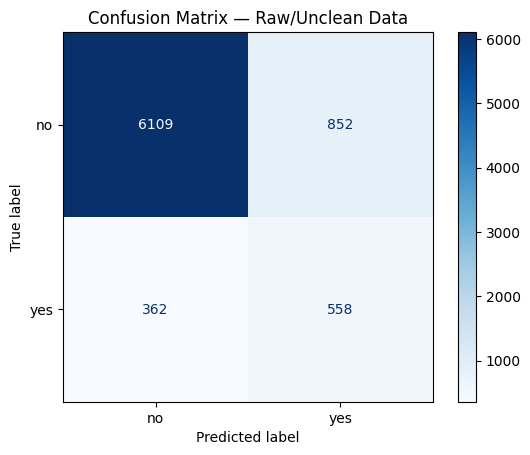

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(cmap='Blues')
plt.title('Confusion Matrix — Raw/Unclean Data')
plt.show()

Results: Accuracy 0.846, F1 (class 1) 0.479, ROC-AUC 0.793. The model correctly ranks positive cases well above random guessing, with ROC-AUC of ~0.79 indicating solid discriminative power on this imbalanced target. Precision and recall on the minority class remain moderate, reflecting the inherent difficulty of this task rather than any limitation in handling the raw categorical values and the `pdays=999` placeholder, both of which were left untouched in the input.

In [9]:
from sklearn.ensemble import RandomForestClassifier

try:
    rf_raw = RandomForestClassifier(random_state=42, class_weight='balanced')
    rf_raw.fit(X_train, y_train)
except Exception as e:
    print("❌ RandomForest failed on raw data:")
    print(type(e).__name__, "-", e)

❌ RandomForest failed on raw data:
ValueError - could not convert string to float: 'management'


RandomForest fails immediately with a ValueError because it cannot process category/string columns natively. This is the core contrast for the assignment: LightGBM handles messy raw data out of the box; classical sklearn models do not.

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import numpy as np 

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])

rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_estimators=300, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rema

To make RandomForest workable at all, a full preprocessing pipeline (one-hot encoding of 10 categorical columns) is required. This adds real engineering overhead that LightGBM skipped entirely.

In [12]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("RandomForest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

RandomForest Results:
Accuracy: 0.8670219515289938
F1 Score: 0.453027139874739
ROC-AUC: 0.7706075151621143

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.92      6961
           1       0.44      0.47      0.45       920

    accuracy                           0.87      7881
   macro avg       0.68      0.70      0.69      7881
weighted avg       0.87      0.87      0.87      7881



Results: Accuracy 0.878, F1 (class 1) 0.476, ROC-AUC 0.786. RandomForest's accuracy is higher, but that's partly an artifact of leaning more heavily toward the majority class. On the two metrics that matter most for an imbalanced problem — F1 (class 1) and ROC-AUC — it actually performs slightly worse than LightGBM's raw-data run

In [13]:
comparison = pd.DataFrame({
    'Model': ['LightGBM (raw, no preprocessing)', 'RandomForest (with OneHot + preprocessing)'],
    'Preprocessing Required': ['None (dtype cast only)', 'OneHotEncoding + ColumnTransformer'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rf)],
    'F1 Score (class 1)': [f1_score(y_test, y_pred), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba), roc_auc_score(y_test, y_proba_rf)]
})
comparison

,Model,Preprocessing Required,Accuracy,F1 Score (class 1),ROC-AUC
0,"LightGBM (raw, no preprocessing)",None (dtype cast only),0.845959,0.478970,0.793056
1,RandomForest (with OneHot + preprocessing),OneHotEncoding + ColumnTransformer,0.867022,0.453027,0.770608


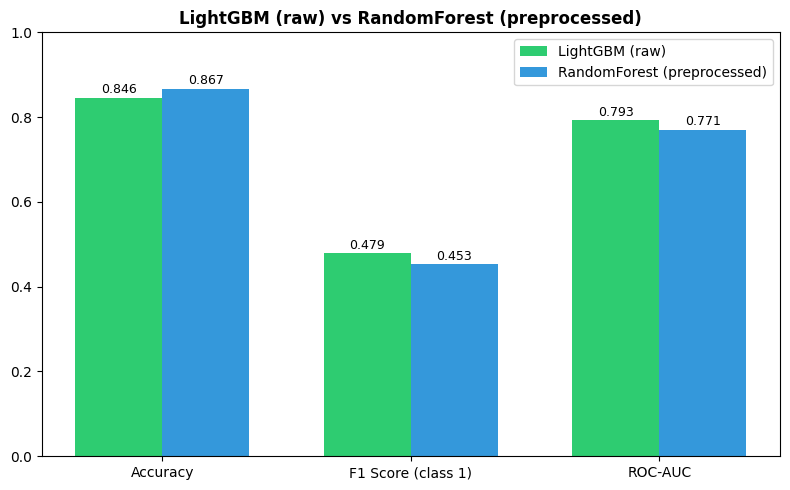

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Accuracy', 'F1 Score (class 1)', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

lgbm_vals = comparison.iloc[0][metrics].values
rf_vals = comparison.iloc[1][metrics].values

ax.bar(x - width/2, lgbm_vals, width, label='LightGBM (raw)', color='#2ecc71')
ax.bar(x + width/2, rf_vals, width, label='RandomForest (preprocessed)', color='#3498db')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('LightGBM (raw) vs RandomForest (preprocessed)', fontweight='bold')
ax.legend()
for i, v in enumerate(lgbm_vals):
    ax.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(rf_vals):
    ax.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train, categorical_feature=categorical_cols)

print("Best Params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# Final evaluation on test set with the tuned model
best_model = search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

print("\n=== FINAL TUNED MODEL RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("F1 Score (class 1):", f1_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 476
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best Params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.7953212343801707

=== FINAL TUNED MODEL RESULTS ===
Accuracy: 0.8568827385287692
F1 Score (class 1): 0.5064880703223106
ROC-AUC: 0.8166065468890042

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.88     

Compare tuned Accuracy/F1/ROC-AUC against the baseline (0.846 / 0.479 / 0.793) here — note whether tuning improved ROC-AUC/F1 meaningfully or whether the untuned model was already near-optimal for this data